# 3. Model Building

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [2]:
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10

DATA_PATH = "data/processed/weather/"

df = pd.read_csv(DATA_PATH + "master_long.csv", parse_dates=["date"])
annual_city = pd.read_csv(DATA_PATH + "annual_city.csv")
global_annual = pd.read_csv(DATA_PATH + "global_annual.csv")

print("Daily data shape :", df.shape)
print("Annual city data shape :", annual_city.shape)
print("Global annual data shape :", global_annual.shape)

Daily data shape : (54795, 22)
Annual city data shape : (150, 14)
Global annual data shape : (10, 7)


### Model 1 : Linear Regression on global annual mean temperature

In [3]:
X = global_annual[["year"]]
y = global_annual["global_temp_mean"]

global_lr = LinearRegression()
global_lr.fit(X, y)

y_pred = global_lr.predict(X)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

slope_per_year = global_lr.coef_[0]
slope_per_decade = slope_per_year * 10

print("MODEL 1 : Global Linear Regression")
print("Slope per year :", round(slope_per_year, 4), "C/year")
print("Slope per decade :", round(slope_per_decade, 3), "C/decade")
print("R2 :", round(r2, 3))
print("MAE :", round(mae, 3), "C")
print("RMSE :", round(rmse, 3), "C")


MODEL 1 : Global Linear Regression
Slope per year : 0.0263 C/year
Slope per decade : 0.263 C/decade
R2 : 0.176
MAE : 0.132 C
RMSE : 0.164 C


### Results are not that good as global mean temperature is not linear

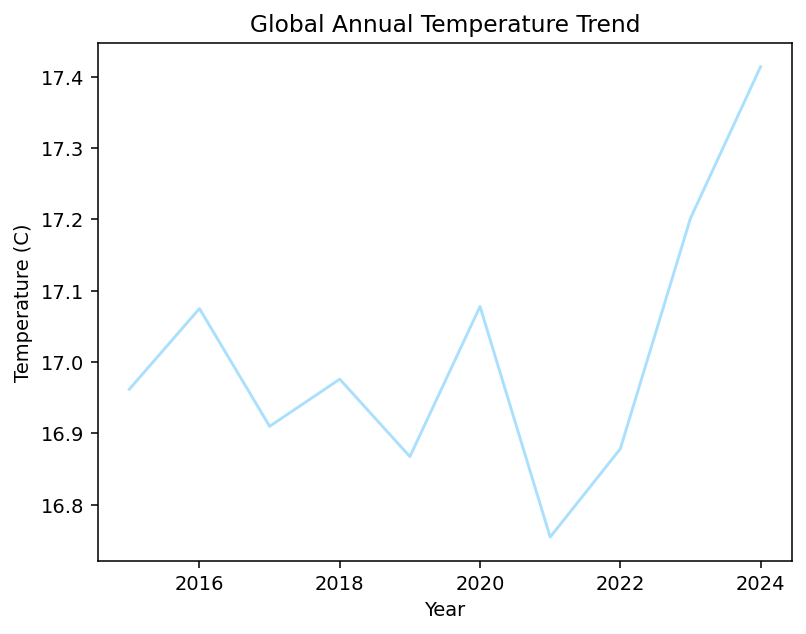

In [6]:
plt.plot(global_annual["year"], global_annual["global_temp_mean"], color="#65c7fc", alpha=0.55, label="Annual mean")
plt.title("Global Annual Temperature Trend")
plt.ylabel("Temperature (C)")
plt.xlabel("Year")
plt.show()

In [54]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

poly_model.fit(X, y)
poly_pred = poly_model.predict(X)

poly_mae = mean_absolute_error(y, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y, poly_pred))
poly_r2 = r2_score(y, poly_pred)

model_compare = pd.DataFrame({
    "model": ["Linear Regression", "Polynomial Regression Degree 2"],
    "MAE": [mae, poly_mae],
    "RMSE": [rmse, poly_rmse],
    "R2": [r2, poly_r2]
})

In [55]:
model_compare

,model,MAE,RMSE,R2
0,Linear Regression,0.132491,0.163636,0.175915
1,Polynomial Regression Degree 2,0.070357,0.091617,0.741674


### Made a model - polynomial regressor of degree 3 with a better r2 score of 0.74

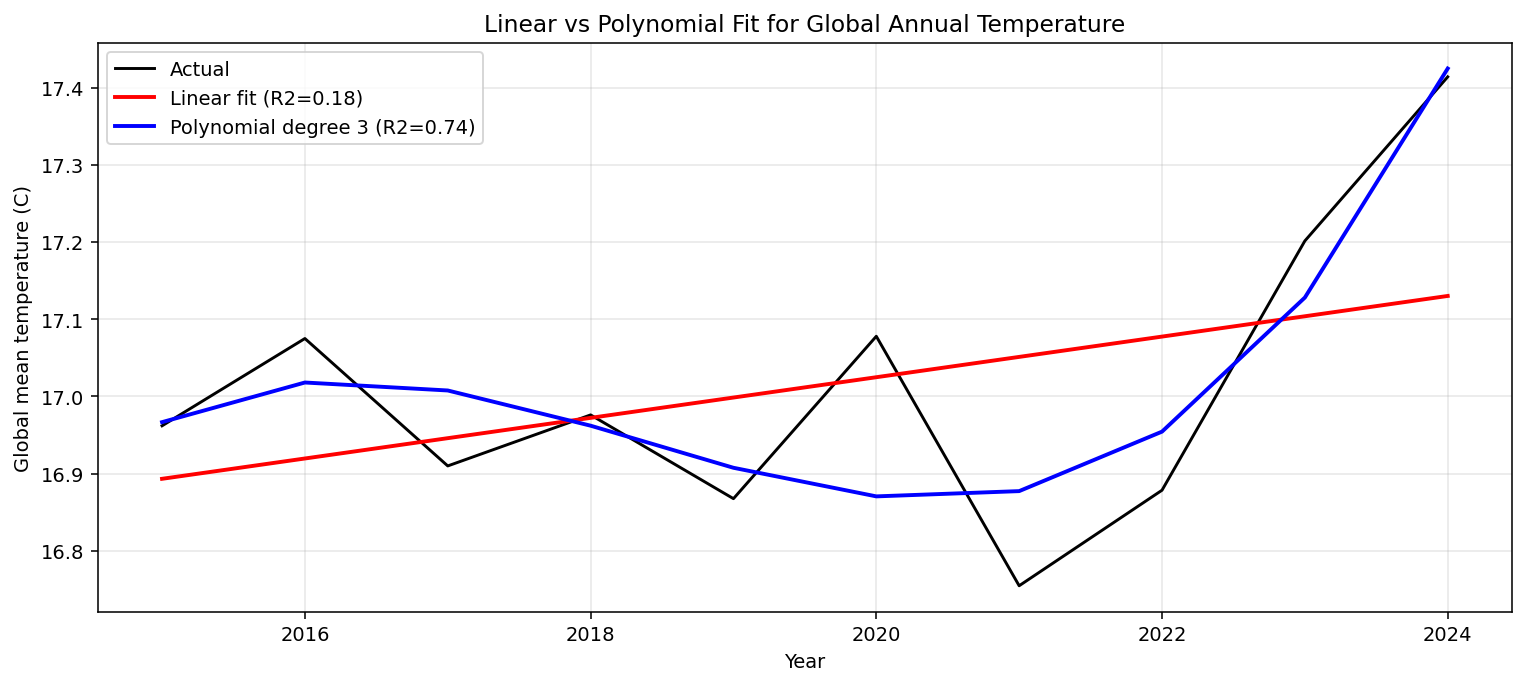

In [56]:
plt.figure(figsize=(11, 5))

plt.plot(global_annual["year"], y, color="black", label="Actual")

plt.plot(
    global_annual["year"],
    y_pred,
    color="red",
    linewidth=2,
    label=f"Linear fit (R2={r2:.2f})"
)

plt.plot(
    global_annual["year"],
    poly_pred,
    color="blue",
    linewidth=2,
    label=f"Polynomial degree 3 (R2={poly_r2:.2f})"
)

plt.title("Linear vs Polynomial Fit for Global Annual Temperature")
plt.xlabel("Year")
plt.ylabel("Global mean temperature (C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Forecasting

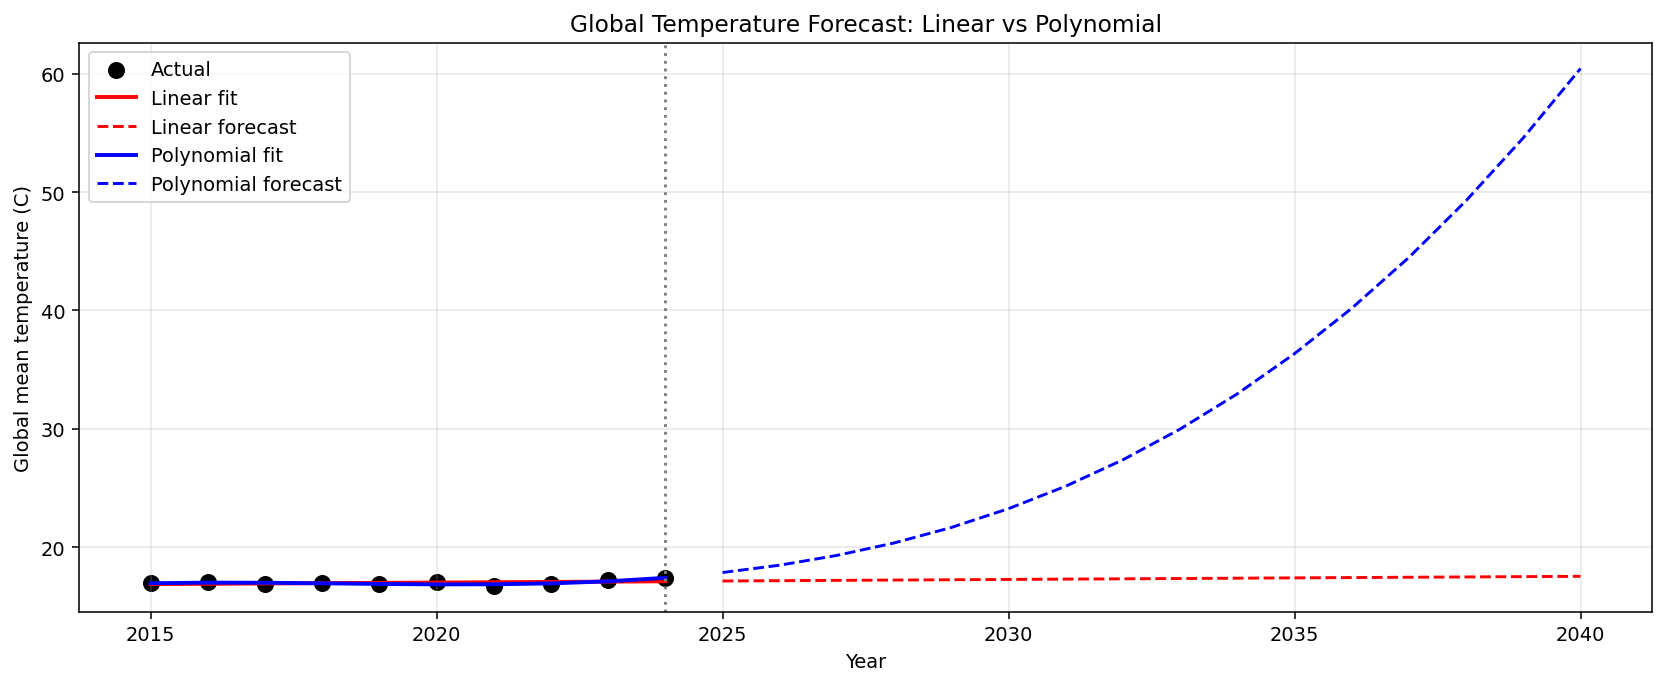

In [57]:
future_years = pd.DataFrame({"year": np.arange(2025, 2041)})

linear_future = global_lr.predict(future_years)
poly_future = poly_model.predict(future_years)

plt.figure(figsize=(12, 5))

plt.scatter(global_annual["year"], y, color="black", s=60, label="Actual")

plt.plot(global_annual["year"], y_pred, color="red", linewidth=2, label="Linear fit")
plt.plot(future_years["year"], linear_future, color="red", linestyle="--", label="Linear forecast")

plt.plot(global_annual["year"], poly_pred, color="blue", linewidth=2, label="Polynomial fit")
plt.plot(future_years["year"], poly_future, color="blue", linestyle="--", label="Polynomial forecast")

plt.axvline(2024, color="gray", linestyle=":")
plt.title("Global Temperature Forecast: Linear vs Polynomial")
plt.xlabel("Year")
plt.ylabel("Global mean temperature (C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### As we have recent increasing trend and no data points after that, so forecasting is done exponential which is not right, so we have to use ARIMA/ SARIMA on monthly variations

## MODEL 2: Continent-wise Linear Regression

1. Continent-wise Linear Model

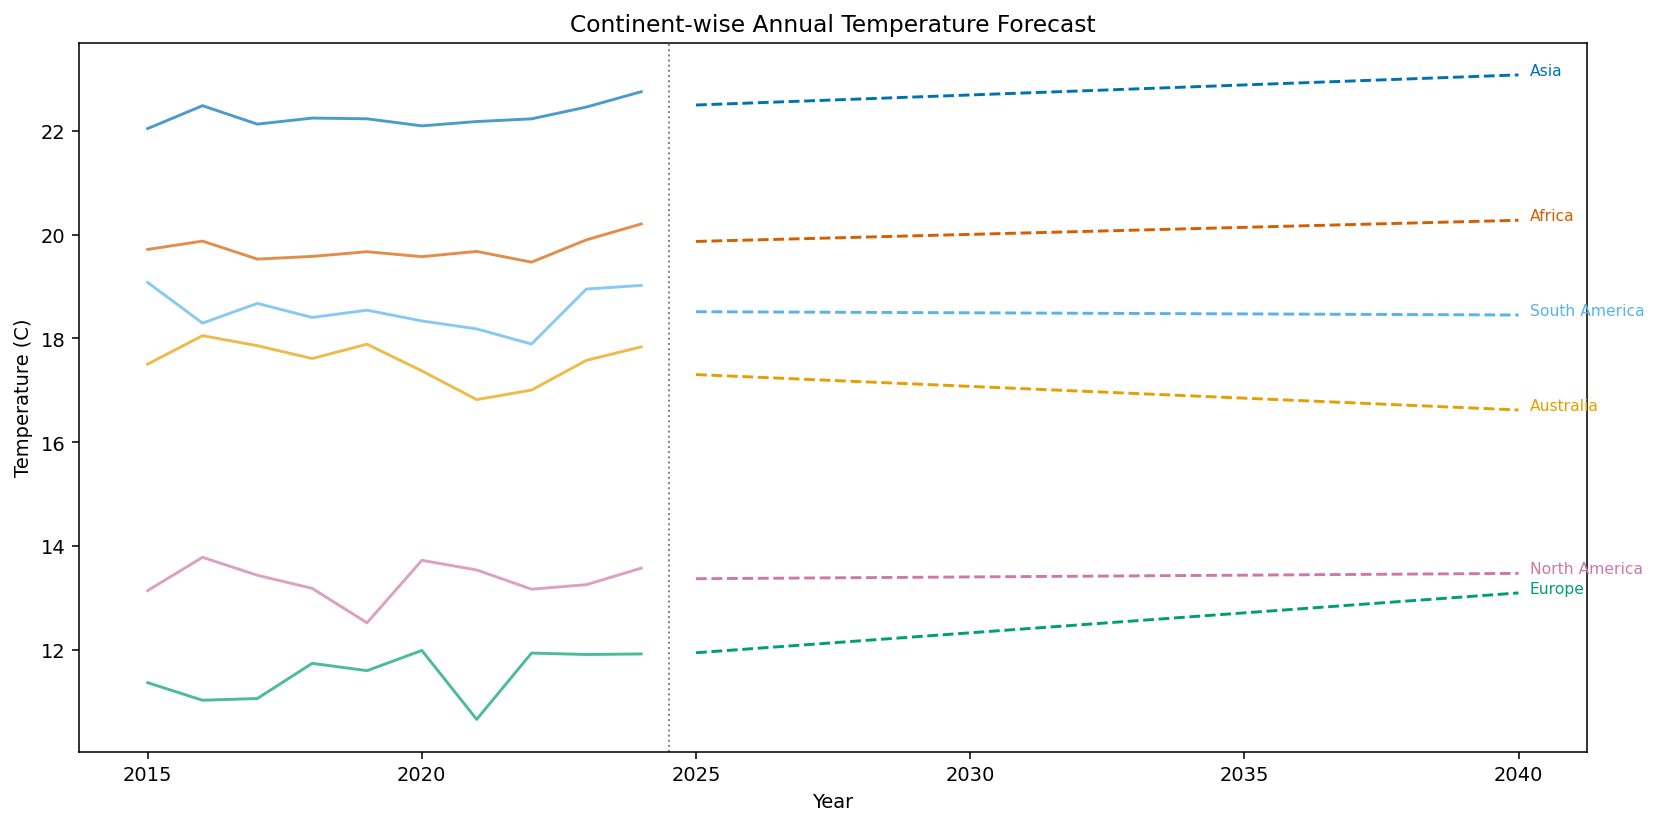

,model,region,mae,rmse,r2,trend_per_decade_C,forecast_2040
3,Linear Regression,Europe,0.293510,0.385764,0.246758,0.768712,13.093387
1,Linear Regression,Asia,0.137148,0.174097,0.289376,0.386791,23.077452
0,Linear Regression,Africa,0.163267,0.193668,0.139843,0.271870,20.275594
4,Linear Regression,North America,0.277971,0.348520,0.003183,0.068571,13.469985
5,Linear Regression,South America,0.316385,0.370789,0.001076,-0.042360,18.449764
2,Linear Regression,Australia,0.303476,0.352381,0.120829,-0.454816,16.619227


In [58]:
future_years = np.arange(2025, 2041)
future_df = pd.DataFrame({"year": future_years})
continent_annual = (
    annual_city
    .groupby(["continent", "year"], as_index=False)["temp_annual_mean"]
    .mean()
)

palette = {
    "Africa": "#D55E00",
    "Asia": "#0072B2",
    "Australia": "#E69F00",
    "Europe": "#009E73",
    "North America": "#CC79A7",
    "South America": "#56B4E9"
}

continent_results = []

plt.figure(figsize=(12, 6))

for continent, data in continent_annual.groupby("continent"):
    data = data.sort_values("year")
    
    X_c = data[["year"]]
    y_c = data["temp_annual_mean"]
    
    model_c = LinearRegression()
    model_c.fit(X_c, y_c)
    
    y_c_pred = model_c.predict(X_c)
    future_c_pred = model_c.predict(future_df)
    
    c_r2 = r2_score(y_c, y_c_pred)
    c_mae = mean_absolute_error(y_c, y_c_pred)
    c_rmse = np.sqrt(mean_squared_error(y_c, y_c_pred))
    c_slope_decade = model_c.coef_[0] * 10
    
    continent_results.append({
        "model": "Linear Regression",
        "region": continent,
        "mae": c_mae,
        "rmse": c_rmse,
        "r2": c_r2,
        "trend_per_decade_C": c_slope_decade,
        "forecast_2040": model_c.predict(pd.DataFrame({"year": [2040]}))[0]
    })
    
    color = palette.get(continent, "gray")
    plt.plot(data["year"], y_c, color=color, linewidth=1.5, alpha=0.7)
    plt.plot(future_years, future_c_pred, color=color, linestyle="--", linewidth=1.5)
    plt.text(2040.2, future_c_pred[-1], continent, fontsize=8, color=color)

plt.axvline(2024.5, color="gray", linestyle=":", linewidth=1)
plt.title("Continent-wise Annual Temperature Forecast")
plt.xlabel("Year")
plt.ylabel("Temperature (C)")
plt.tight_layout()
plt.show()

continent_results_df = pd.DataFrame(continent_results)
continent_results_df.sort_values("trend_per_decade_C", ascending=False)


## Bad results due to same reason 

To reduce the expontial thing, I have used deg=2 sacrifising the training r2 score a little but reducing the exponential stuff

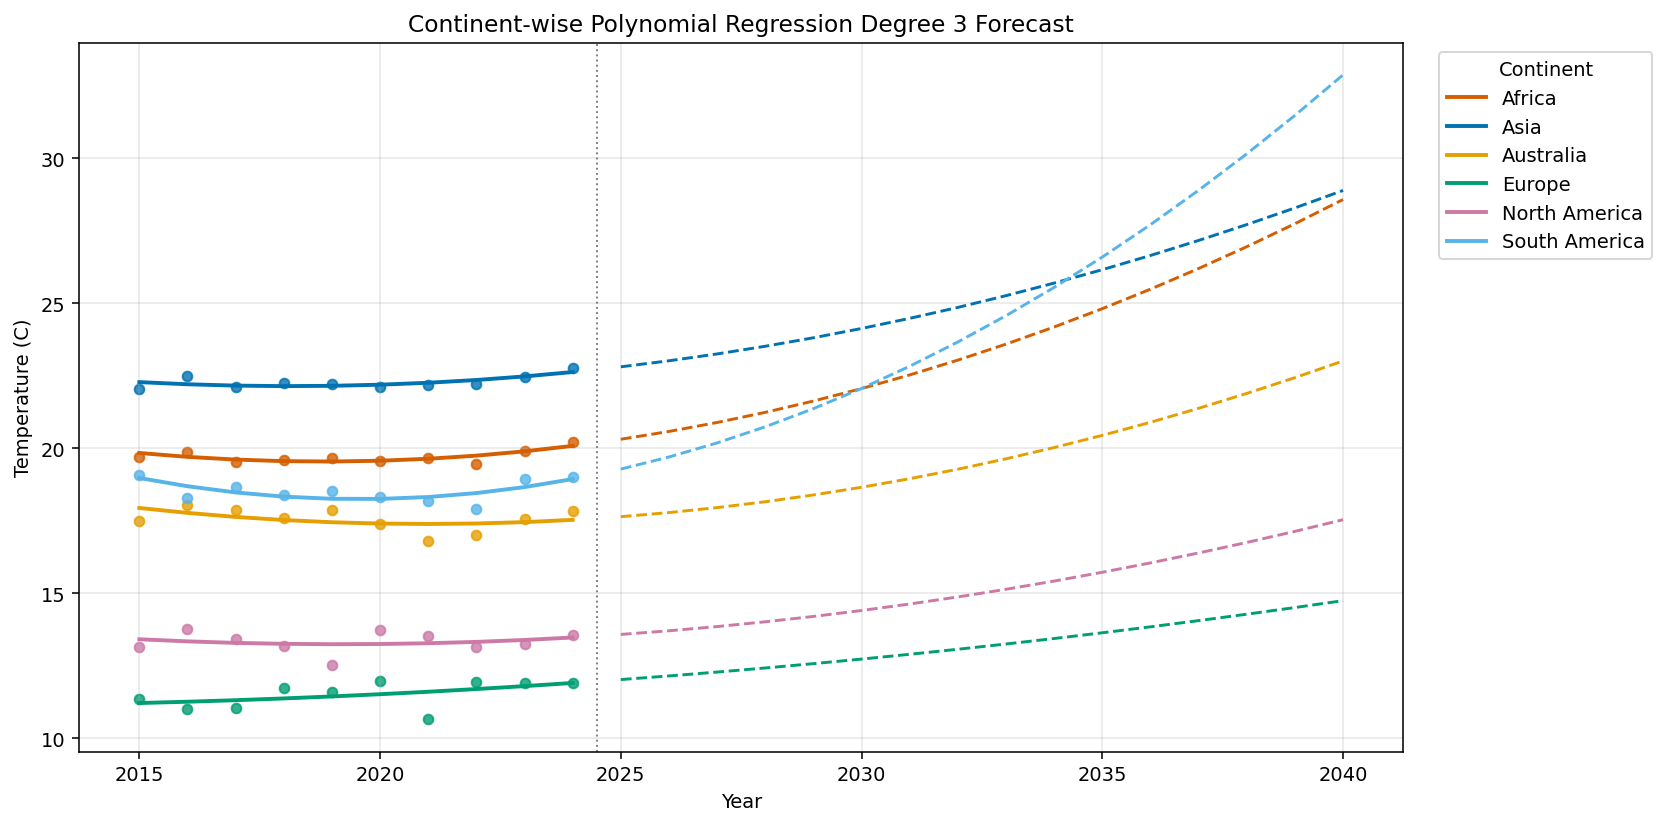

,model,region,mae,rmse,r2,forecast_2040
0,Polynomial Regression Degree 3,Africa,0.096935,0.126872,0.630858,28.572135
1,Polynomial Regression Degree 3,Asia,0.117101,0.140768,0.535419,28.885881
5,Polynomial Regression Degree 3,South America,0.220469,0.269846,0.470934,32.868408
3,Polynomial Regression Degree 3,Europe,0.290297,0.384659,0.251069,14.748136
2,Polynomial Regression Degree 3,Australia,0.289241,0.333874,0.210752,23.009063
4,Polynomial Regression Degree 3,North America,0.277971,0.341055,0.045430,17.538127


In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


continent_poly_results = []

plt.figure(figsize=(12, 6))

for continent, data in continent_annual.groupby("continent"):
    data = data.sort_values("year")
    
    X_c = data[["year"]]
    y_c = data["temp_annual_mean"]
    
    poly_c = make_pipeline(
        PolynomialFeatures(degree=2),
        LinearRegression()
    )
    
    poly_c.fit(X_c, y_c)
    
    y_c_pred = poly_c.predict(X_c)
    future_c_pred = poly_c.predict(future_df)
    
    c_r2 = r2_score(y_c, y_c_pred)
    c_mae = mean_absolute_error(y_c, y_c_pred)
    c_rmse = np.sqrt(mean_squared_error(y_c, y_c_pred))
    
    continent_poly_results.append({
        "model": "Polynomial Regression Degree 3",
        "region": continent,
        "mae": c_mae,
        "rmse": c_rmse,
        "r2": c_r2,
        "forecast_2040": poly_c.predict(pd.DataFrame({"year": [2040]}))[0]
    })
    
    color = palette.get(continent, "gray")
    
    plt.scatter(data["year"], y_c, color=color, s=25, alpha=0.8)
    plt.plot(data["year"], y_c_pred, color=color, linewidth=2, label=continent)
    plt.plot(future_years, future_c_pred, color=color, linestyle="--", linewidth=1.5)

plt.axvline(2024.5, color="gray", linestyle=":", linewidth=1)
plt.title("Continent-wise Polynomial Regression Degree 3 Forecast")
plt.xlabel("Year")
plt.ylabel("Temperature (C)")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

continent_poly_results_df = pd.DataFrame(continent_poly_results)
continent_poly_results_df.sort_values("r2", ascending=False)

# Models to be deployed to streamlit:
1. Linear Regression : Continent and City
(Dropping Polynomial one as its exponentially rising)
2. SARIMA : Continent and City

2.City-wise Linear Model 

In [ ]:
city_linear_results = []
city_forecasts = []

for city, data in annual_city.groupby("city"):
    data = data.sort_values("year")
    
    X = data[["year"]]
    y = data["temp_annual_mean"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    pred = model.predict(X)
    future_pred = model.predict(future_df)
    
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    slope_decade = model.coef_[0] * 10
    
    city_linear_results.append({
        "city": city,
        "country": data["country"].iloc[0],
        "continent": data["continent"].iloc[0],
        "model": "Linear Regression",
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "trend_per_decade_C": slope_decade,
        "forecast_2040": future_pred[-1]
    })
    
    temp_forecast = pd.DataFrame({
        "city": city,
        "country": data["country"].iloc[0],
        "continent": data["continent"].iloc[0],
        "year": future_years,
        "forecast_temp_mean": future_pred
    })
    city_forecasts.append(temp_forecast)



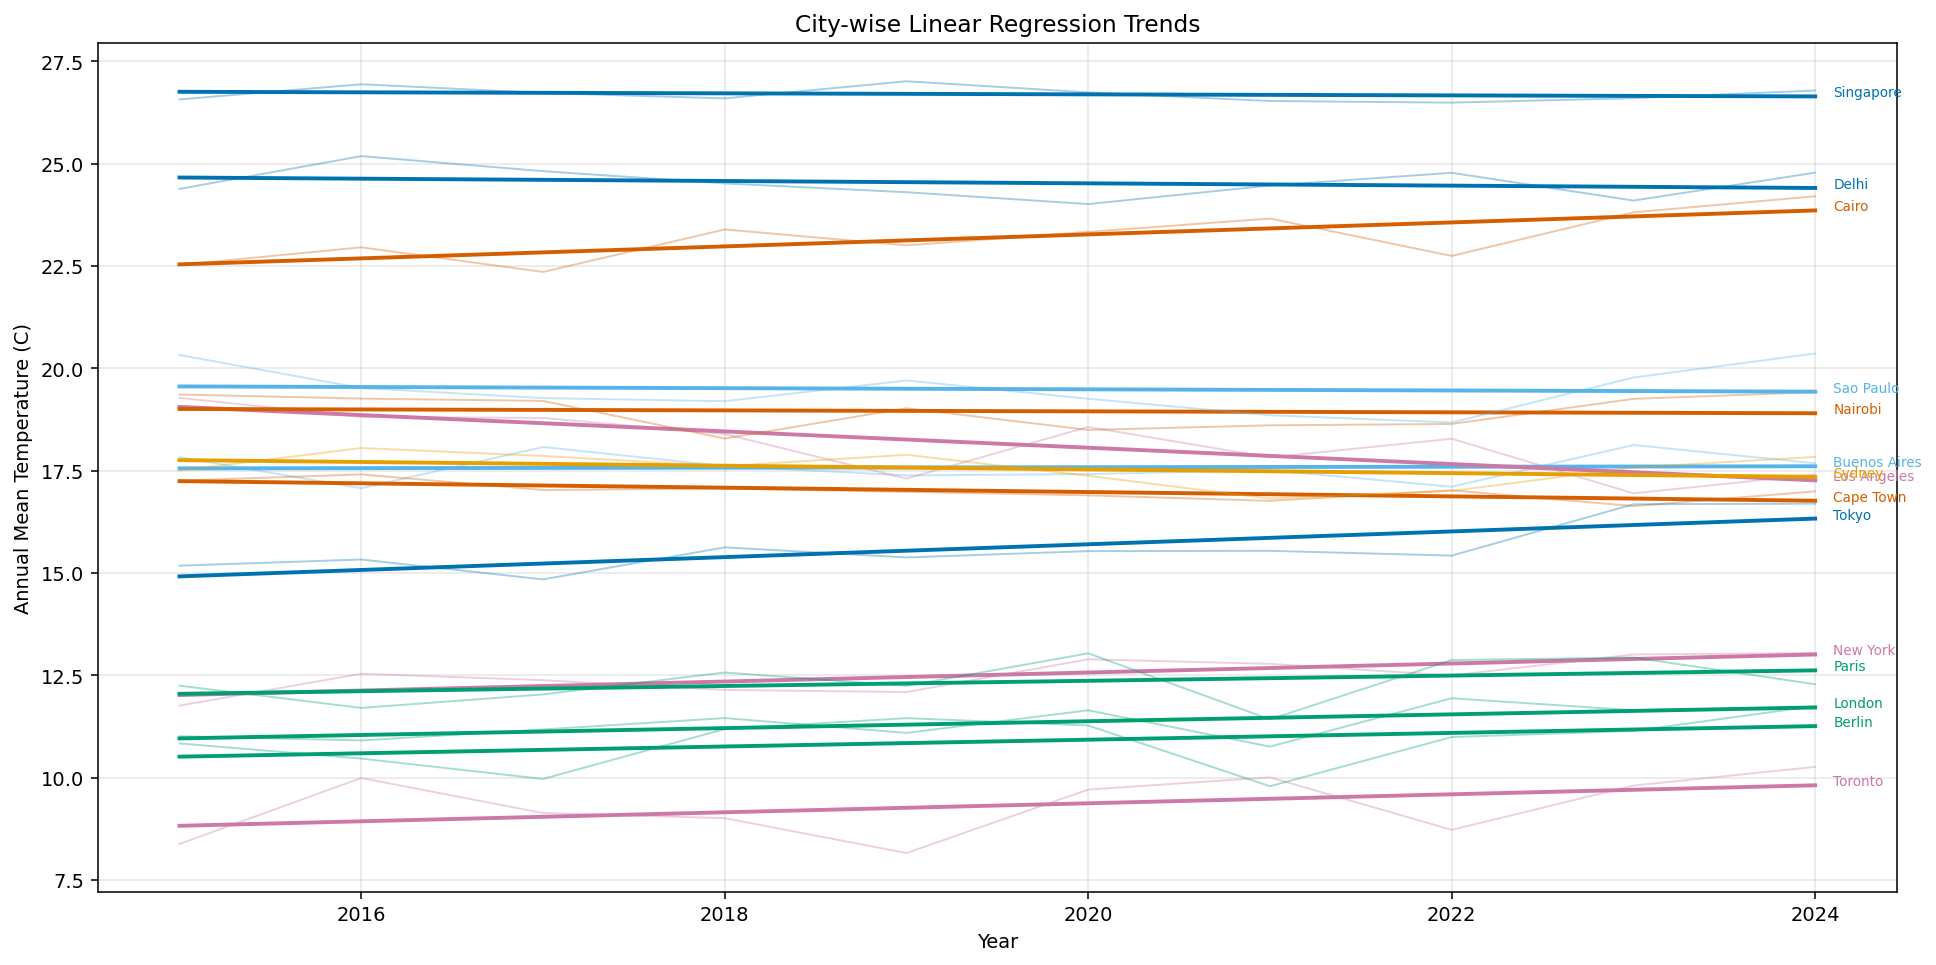

,city,country,continent,trend_per_decade_C,r2
13,Tokyo,Japan,Asia,1.568888,0.621947
2,Cairo,Egypt,Africa,1.464180,0.567240
8,New York,USA,North America,1.100916,0.607768
14,Toronto,Canada,North America,1.099521,0.202754
5,London,United Kingdom,Europe,0.840149,0.407697
0,Berlin,Germany,Europe,0.829483,0.157406
9,Paris,France,Europe,0.636506,0.131712
1,Buenos Aires,Argentina,South America,0.056730,0.002265
7,Nairobi,Kenya,Africa,-0.116566,0.007440
11,Singapore,Singapore,Asia,-0.125088,0.046702


In [65]:
plt.figure(figsize=(14, 7))

city_linear_results = []

for city, data in annual_city.groupby("city"):
    data = data.sort_values("year")
    
    X_city = data[["year"]]
    y_city = data["temp_annual_mean"]
    
    city_model = LinearRegression()
    city_model.fit(X_city, y_city)
    
    y_city_pred = city_model.predict(X_city)
    slope_decade = city_model.coef_[0] * 10
    
    city_linear_results.append({
        "city": city,
        "country": data["country"].iloc[0],
        "continent": data["continent"].iloc[0],
        "trend_per_decade_C": slope_decade,
        "r2": r2_score(y_city, y_city_pred)
    })
    
    color = palette.get(data["continent"].iloc[0], "gray")
    
    plt.plot(
        data["year"],
        y_city,
        color=color,
        alpha=0.35,
        linewidth=1
    )
    
    plt.plot(
        data["year"],
        y_city_pred,
        color=color,
        linewidth=2
    )
    
    plt.text(
        data["year"].iloc[-1] + 0.1,
        y_city_pred[-1],
        city,
        fontsize=7,
        color=color
    )

plt.title("City-wise Linear Regression Trends")
plt.xlabel("Year")
plt.ylabel("Annual Mean Temperature (C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

city_linear_results_df = pd.DataFrame(city_linear_results)
city_linear_results_df.sort_values("trend_per_decade_C", ascending=False)


3. Continent-wise SARIMA

In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

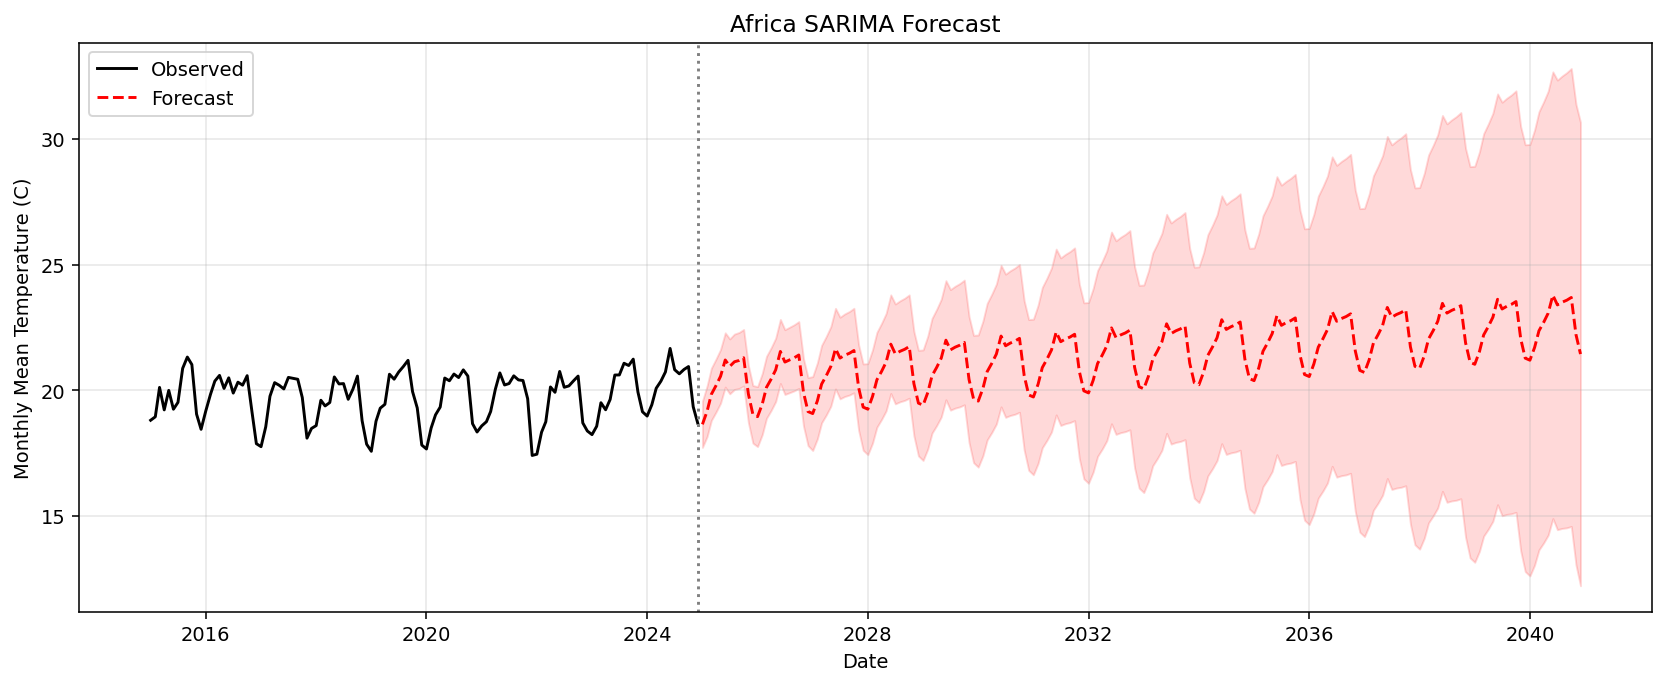

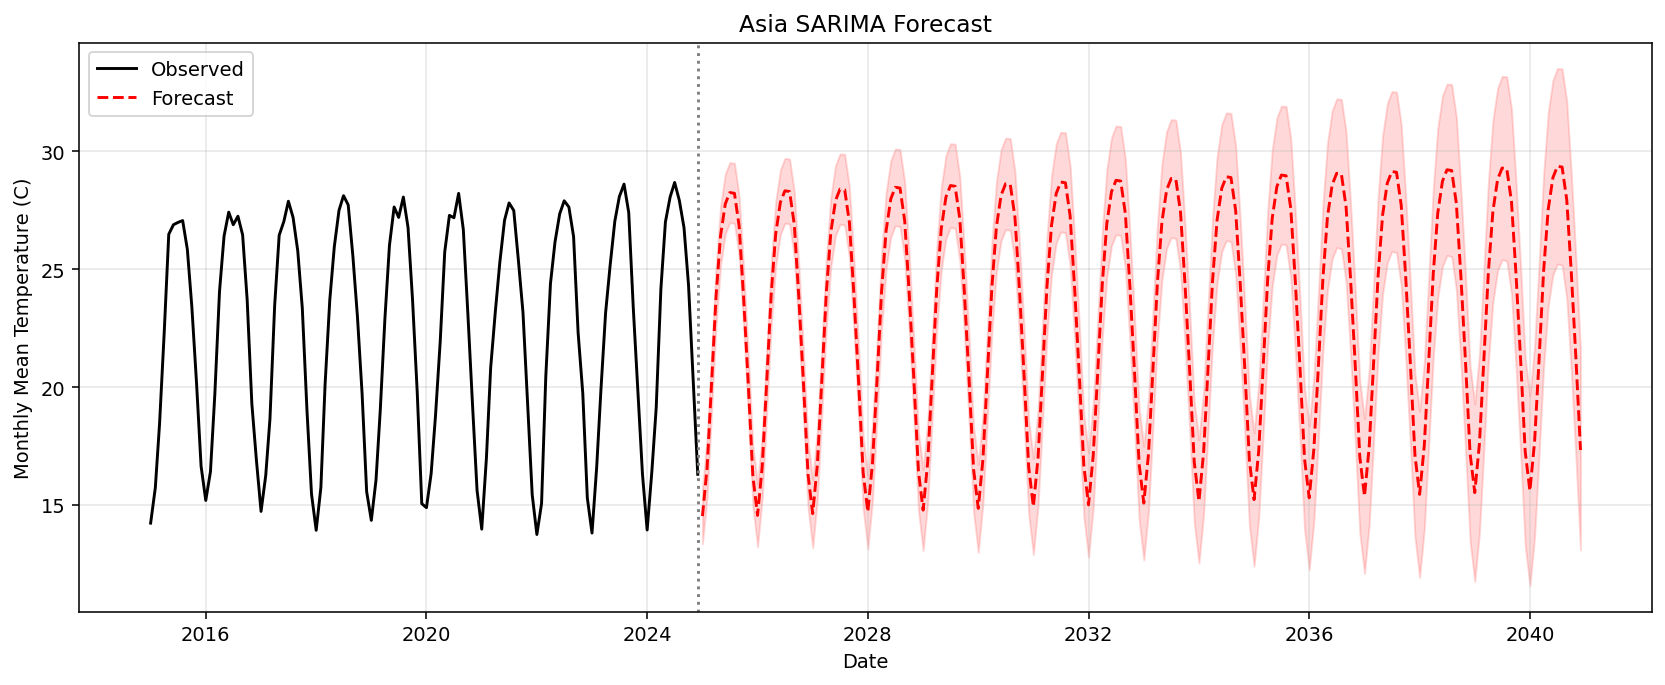

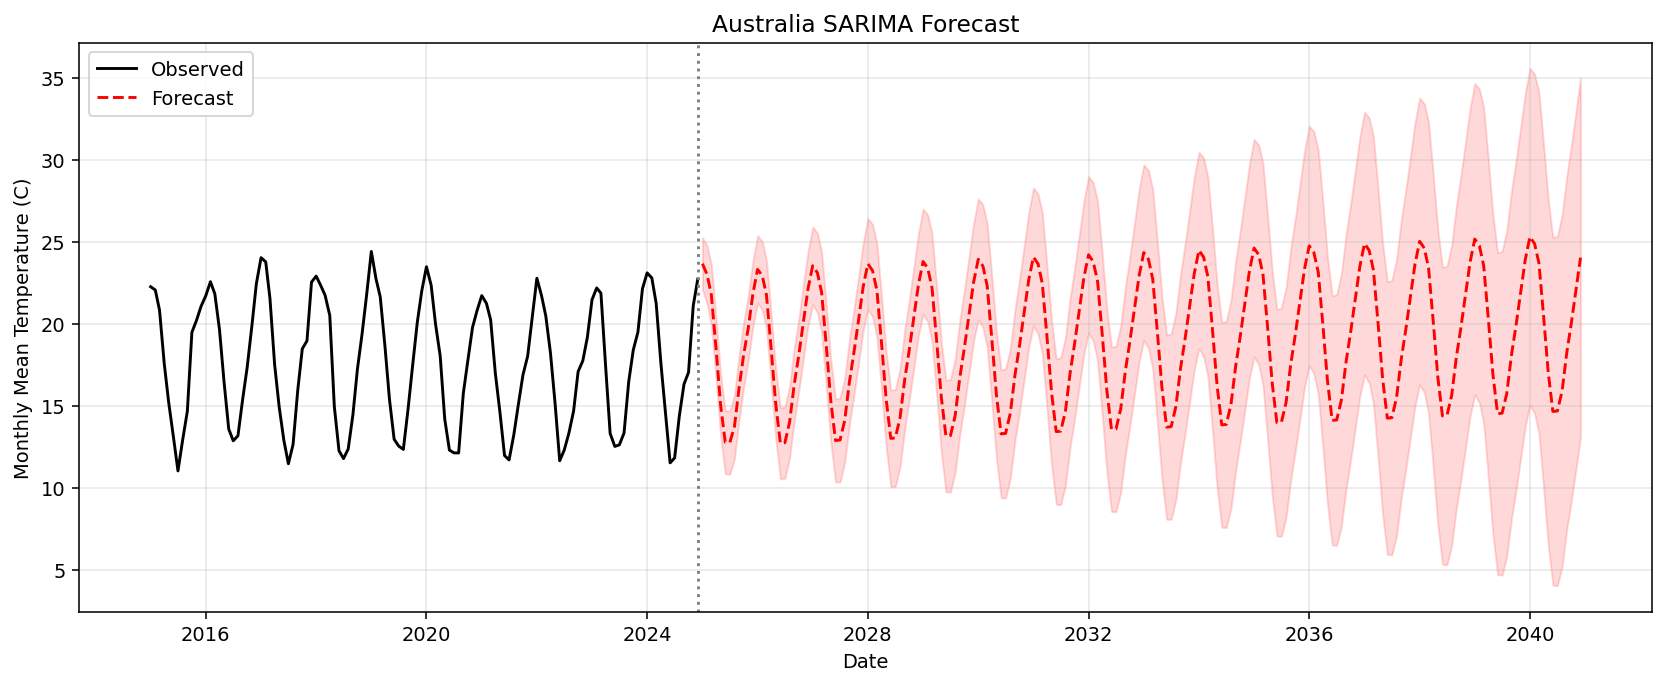

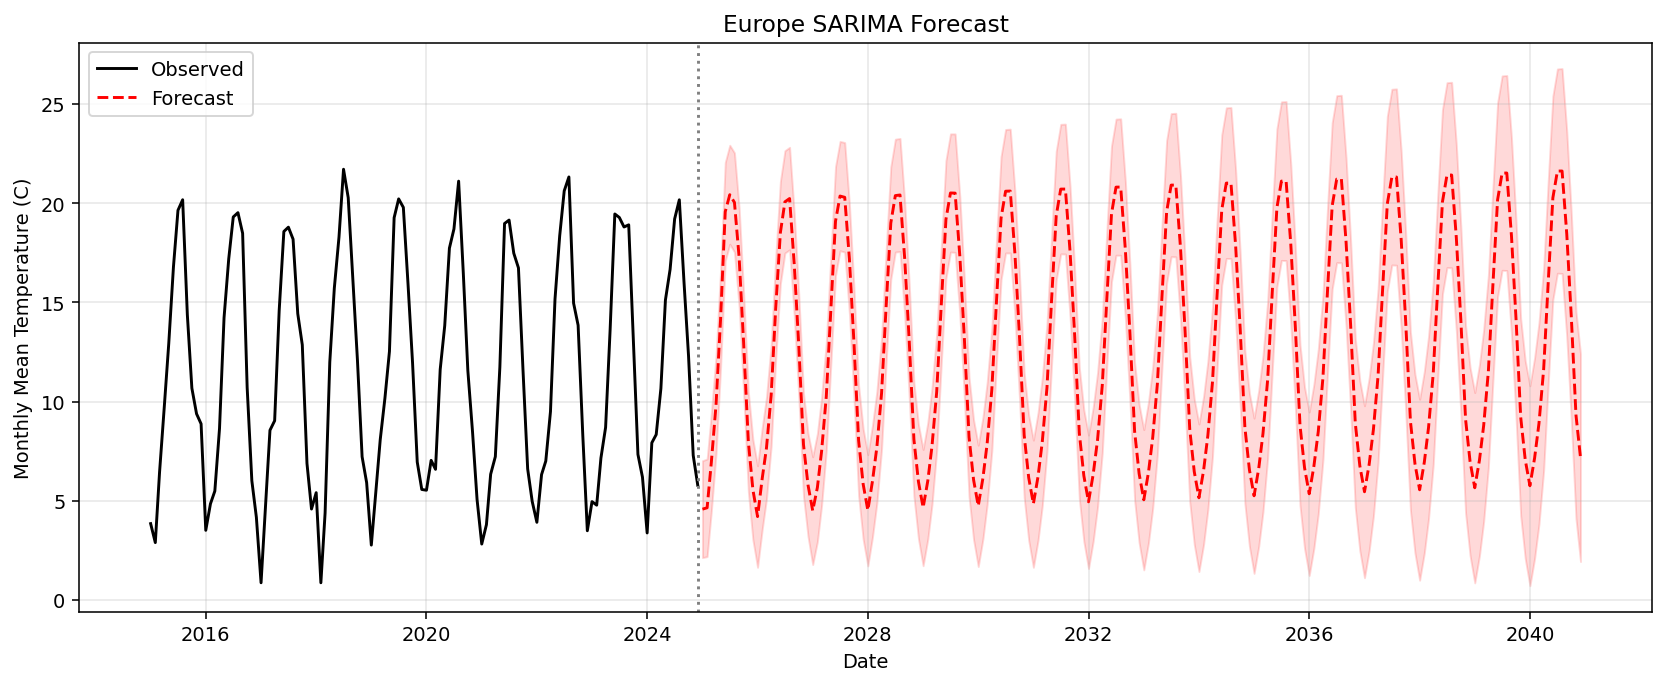

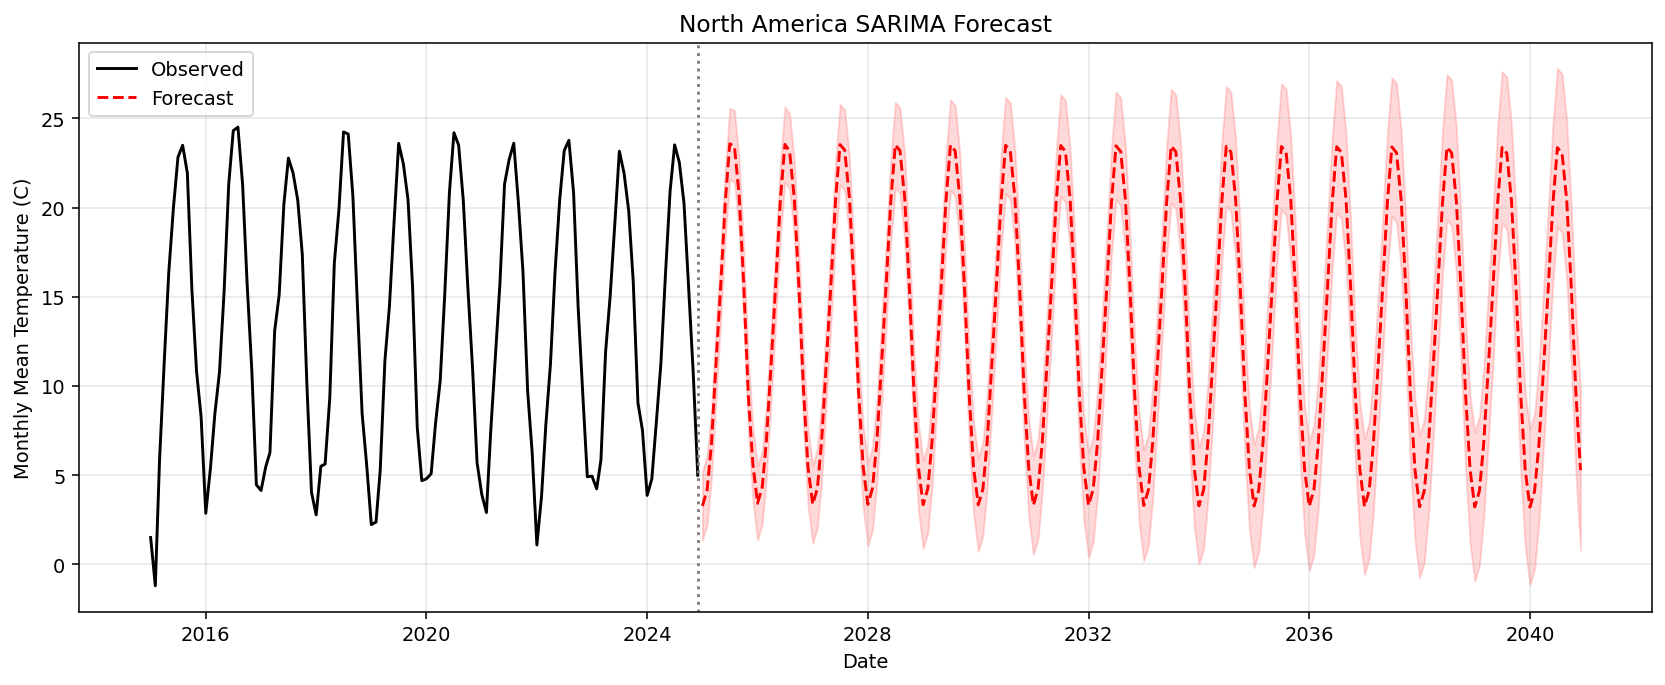

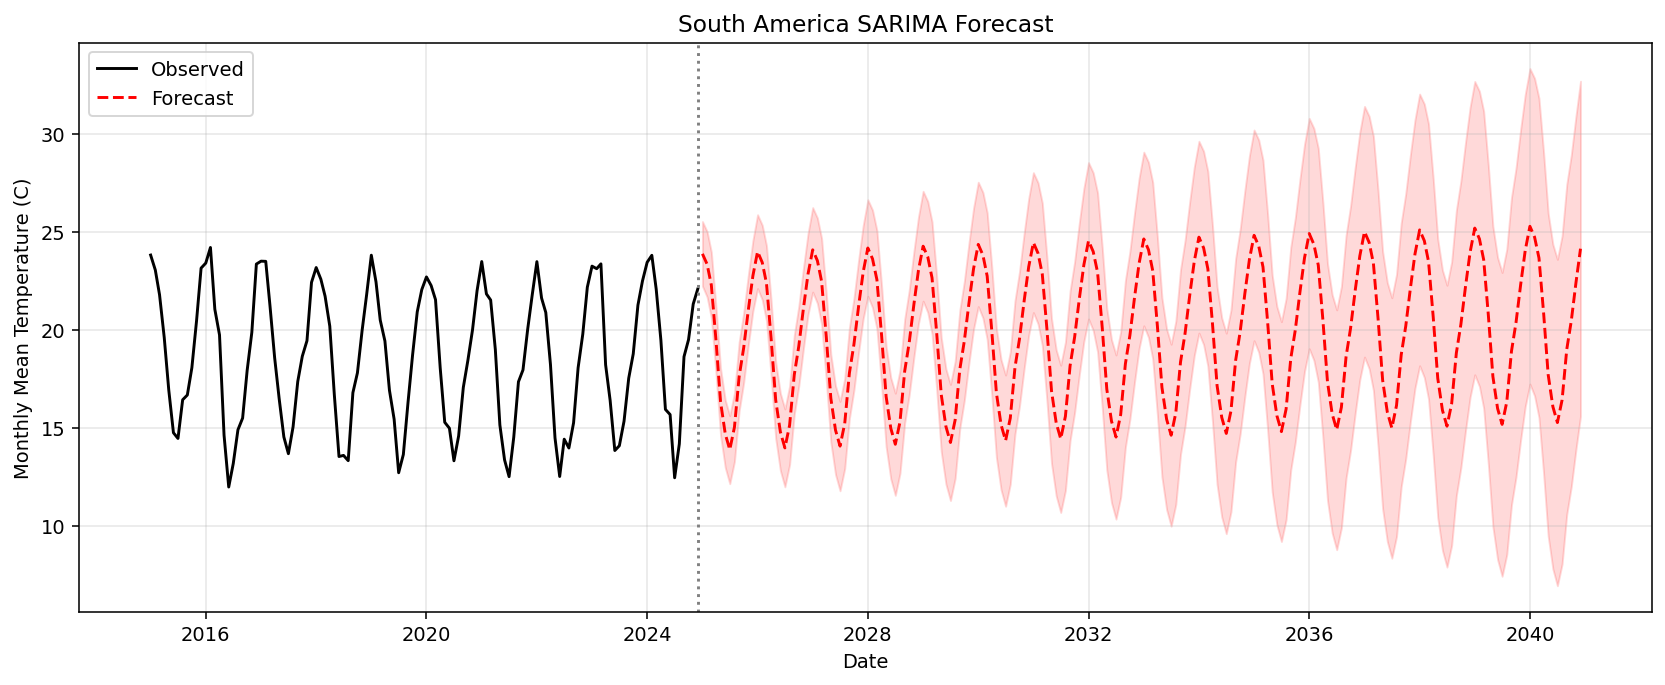

In [68]:
for continent, data in df.groupby("continent"):
    monthly_series = data.groupby(data["date"].dt.to_period("M"))["temp_mean"].mean()
    monthly_series.index = monthly_series.index.to_timestamp()
    monthly_series = monthly_series.resample("MS").mean().interpolate()

    train = monthly_series[: "2022-12-01"]

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    final_model = SARIMAX(
        monthly_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    final_fit = final_model.fit(disp=False)

    future_steps = len(pd.date_range(
        start=monthly_series.index.max() + pd.DateOffset(months=1),
        end="2040-12-01",
        freq="MS"
    ))

    future_forecast_obj = final_fit.get_forecast(steps=future_steps)
    future_forecast = future_forecast_obj.predicted_mean
    future_ci = future_forecast_obj.conf_int()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_series.index, monthly_series.values, color="black", label="Observed")
    plt.plot(future_forecast.index, future_forecast.values, color="red", linestyle="--", label="Forecast")
    plt.fill_between(
        future_forecast.index,
        future_ci.iloc[:, 0],
        future_ci.iloc[:, 1],
        color="red",
        alpha=0.15
    )

    plt.axvline(pd.Timestamp("2024-12-01"), color="gray", linestyle=":")
    plt.title(f"{continent} SARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Monthly Mean Temperature (C)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


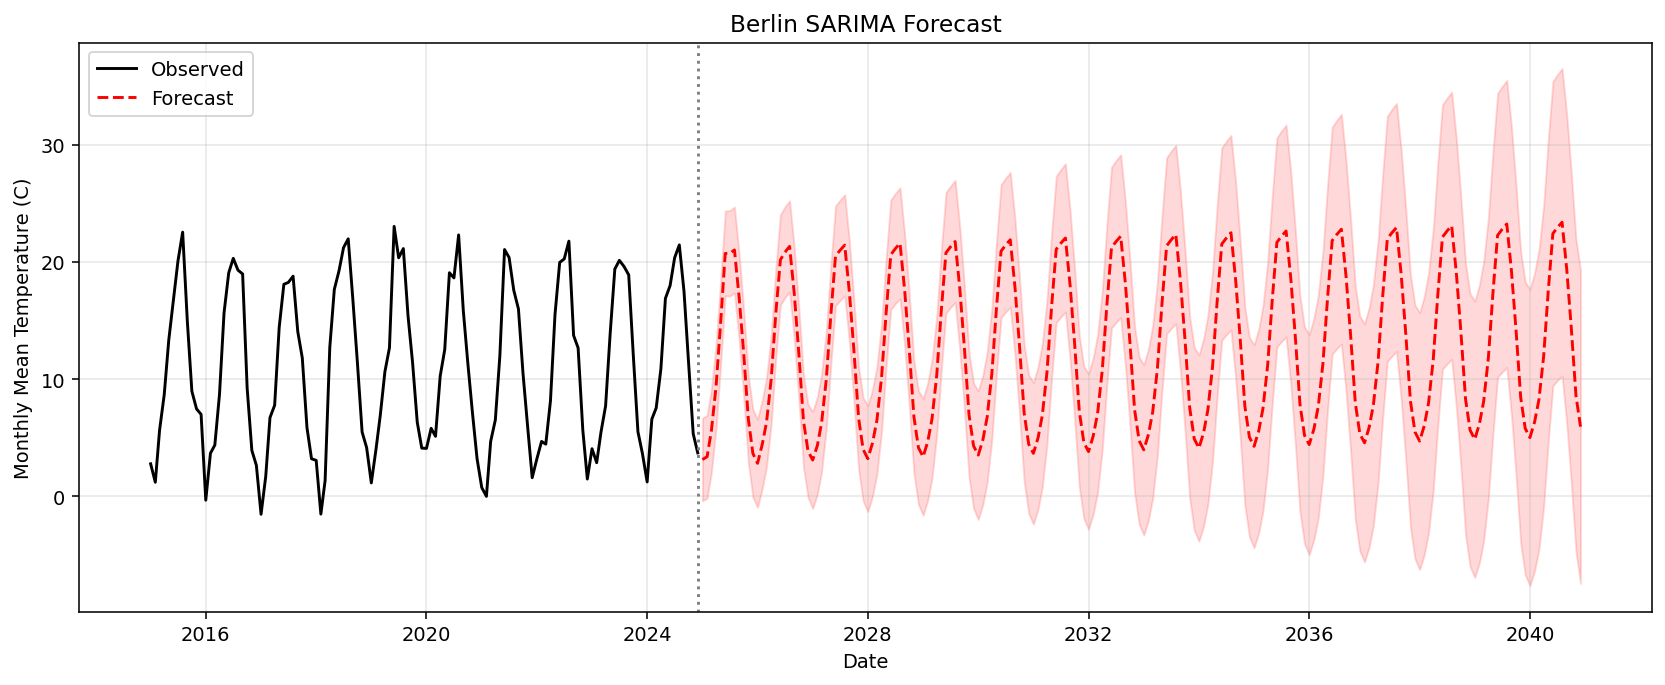

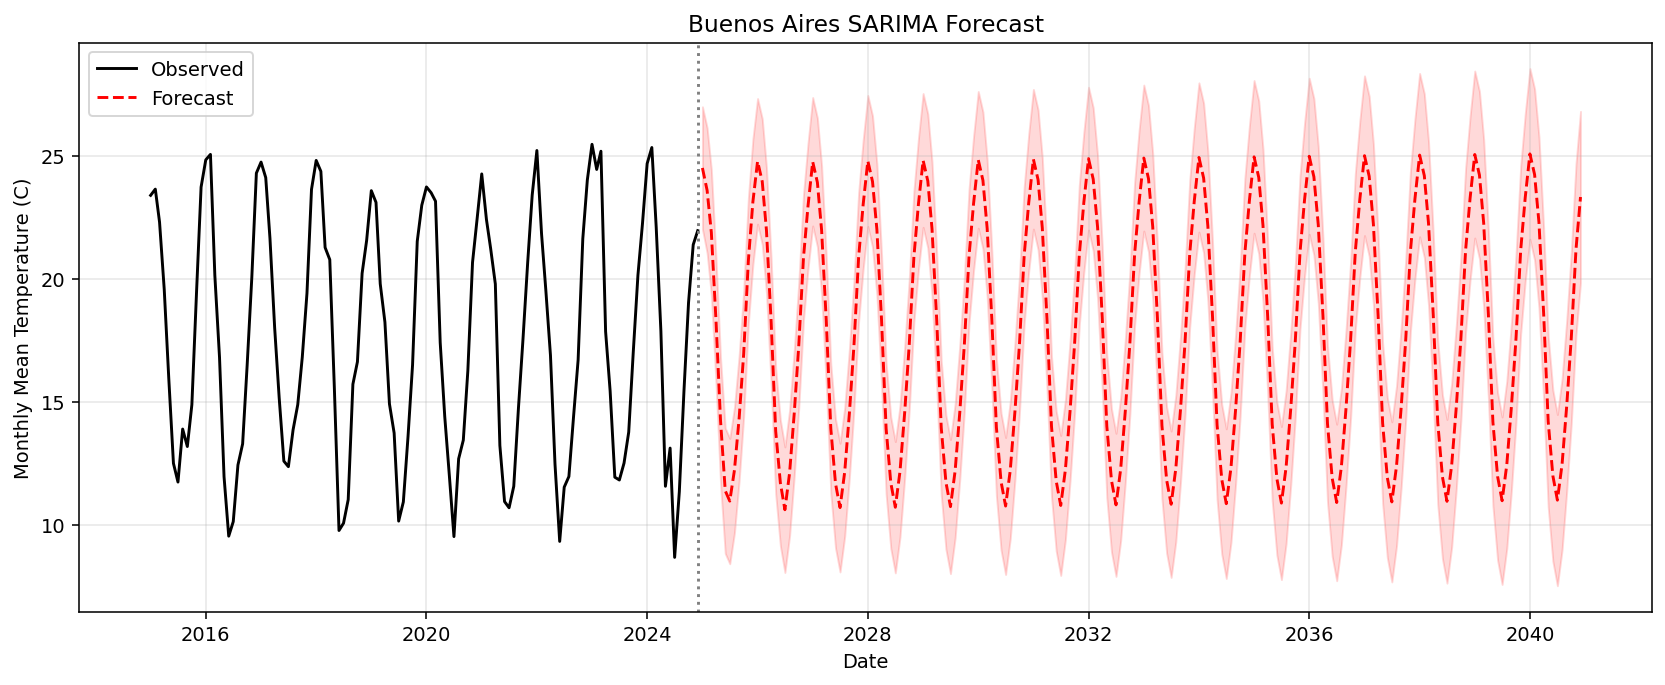

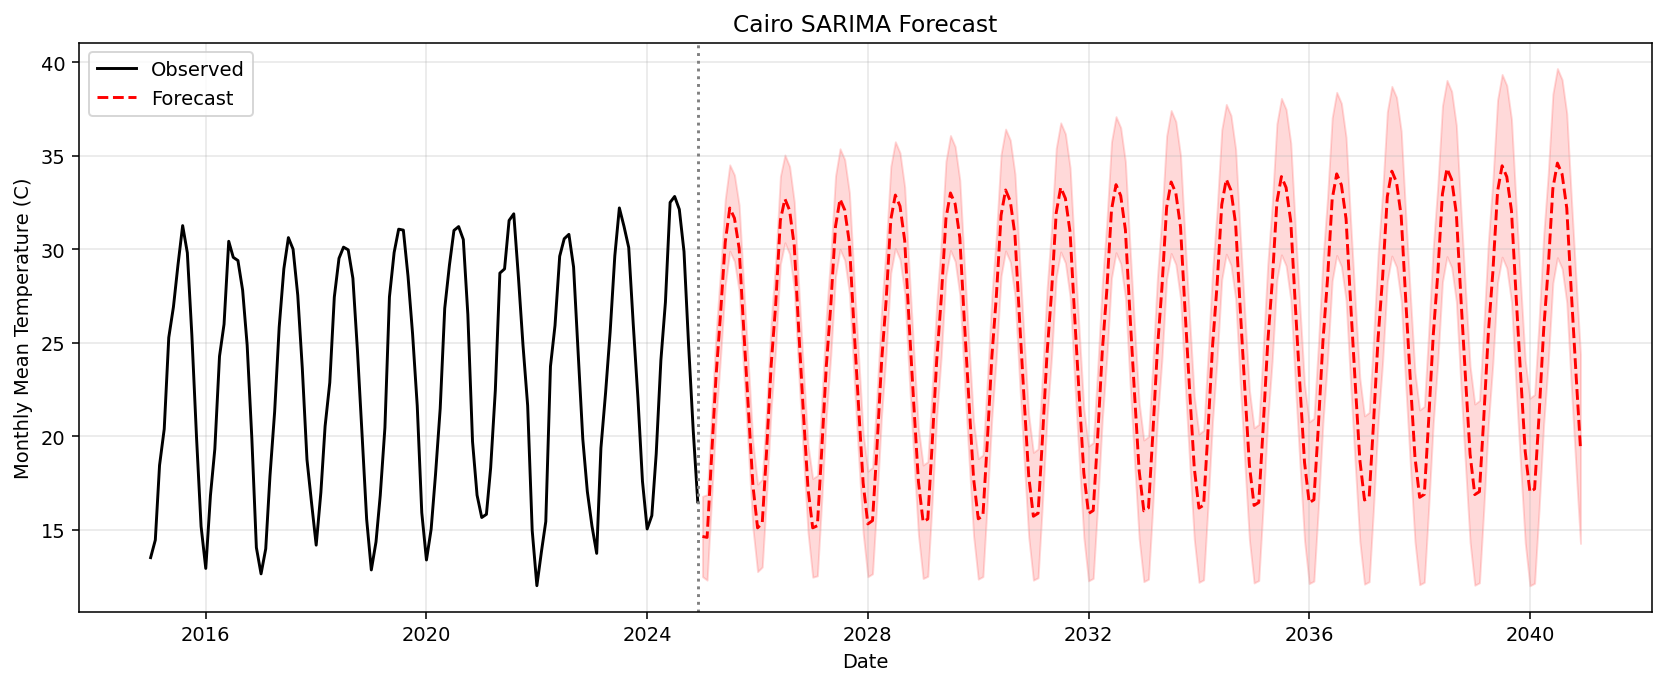

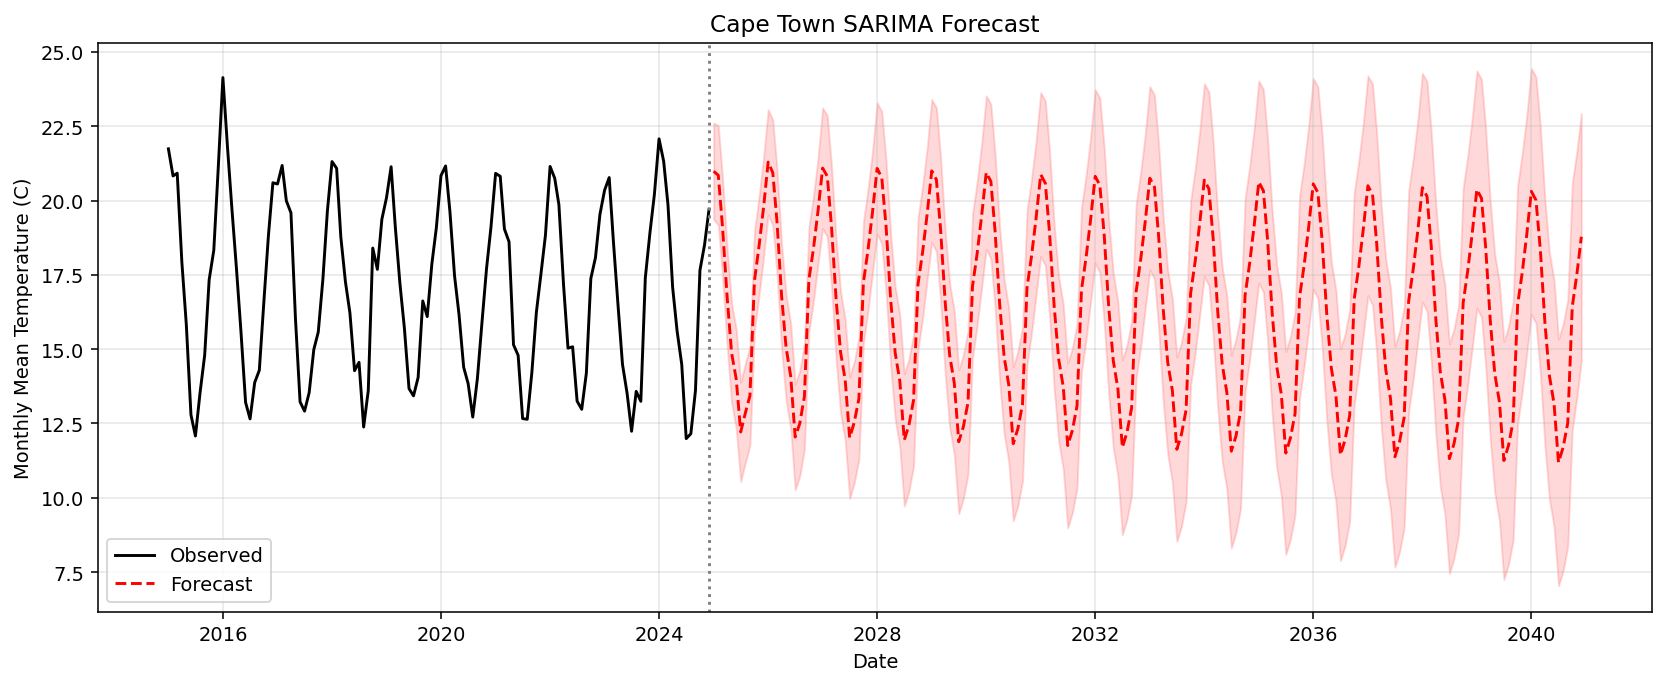

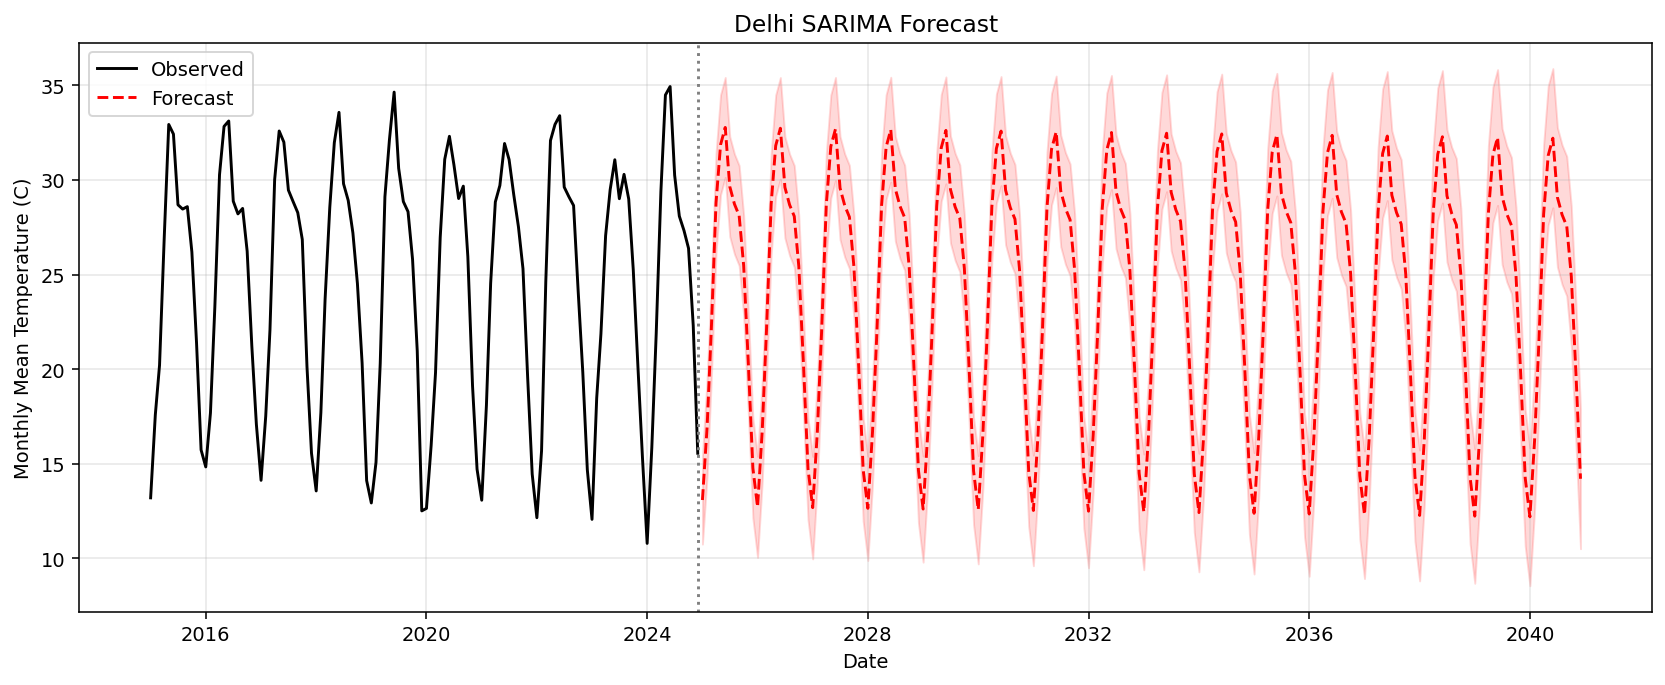

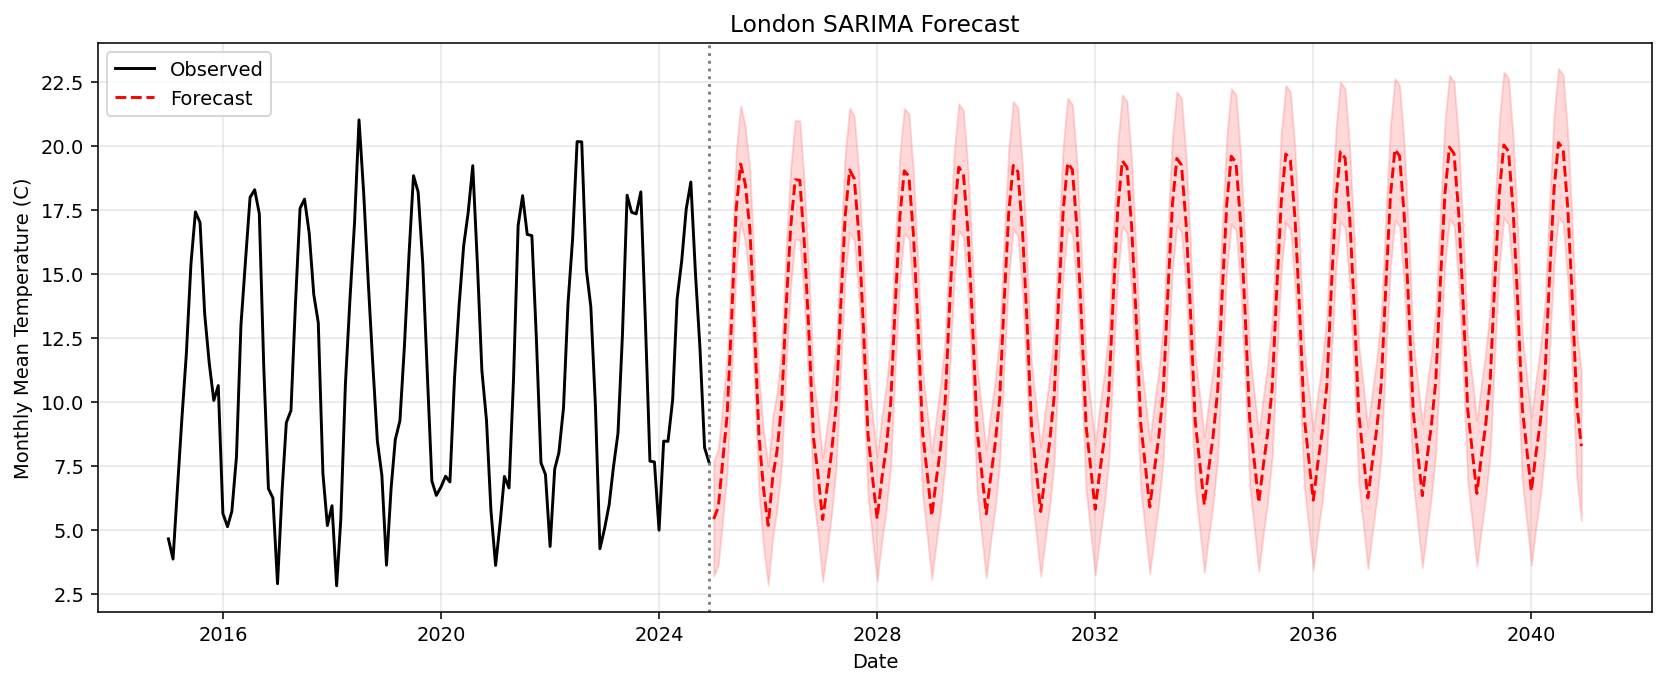

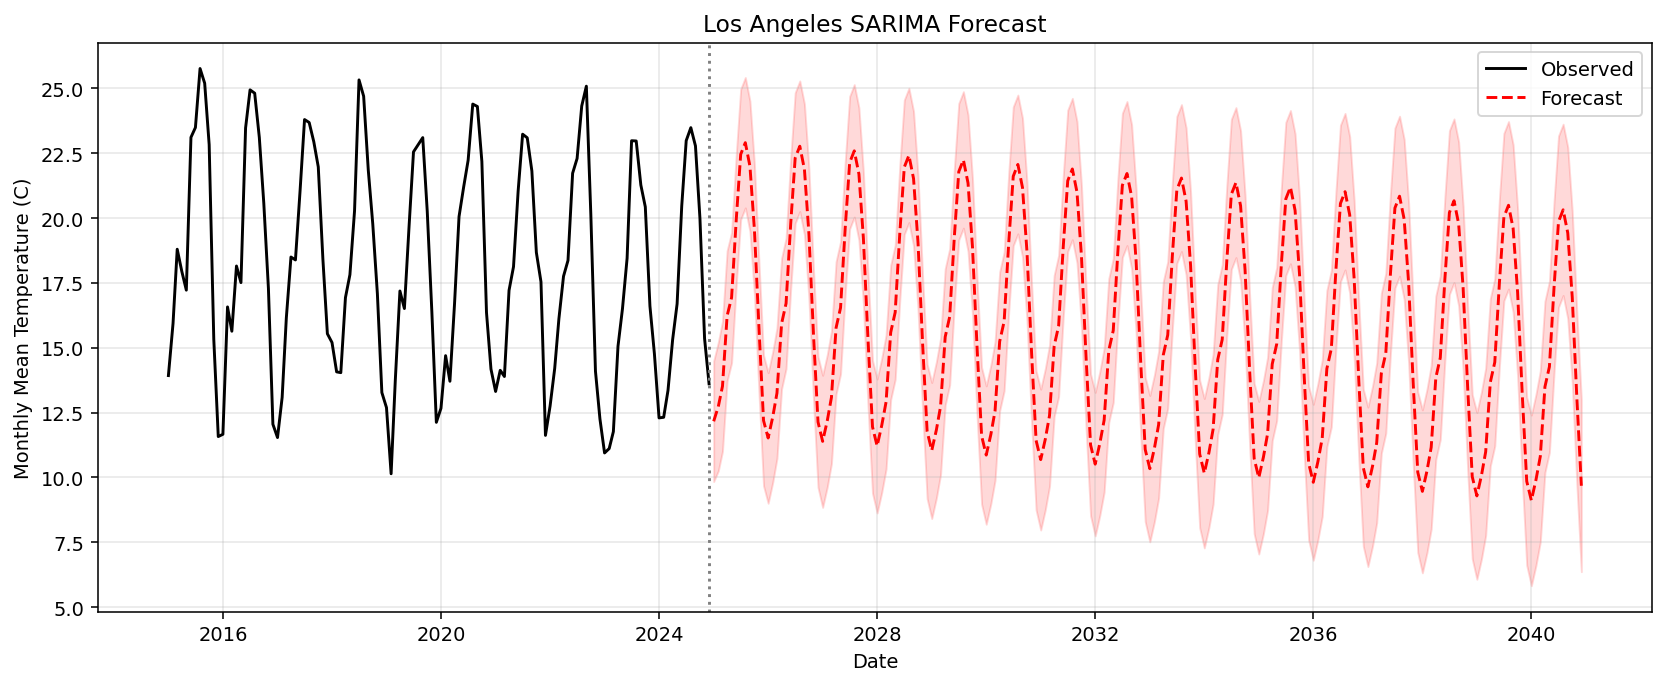

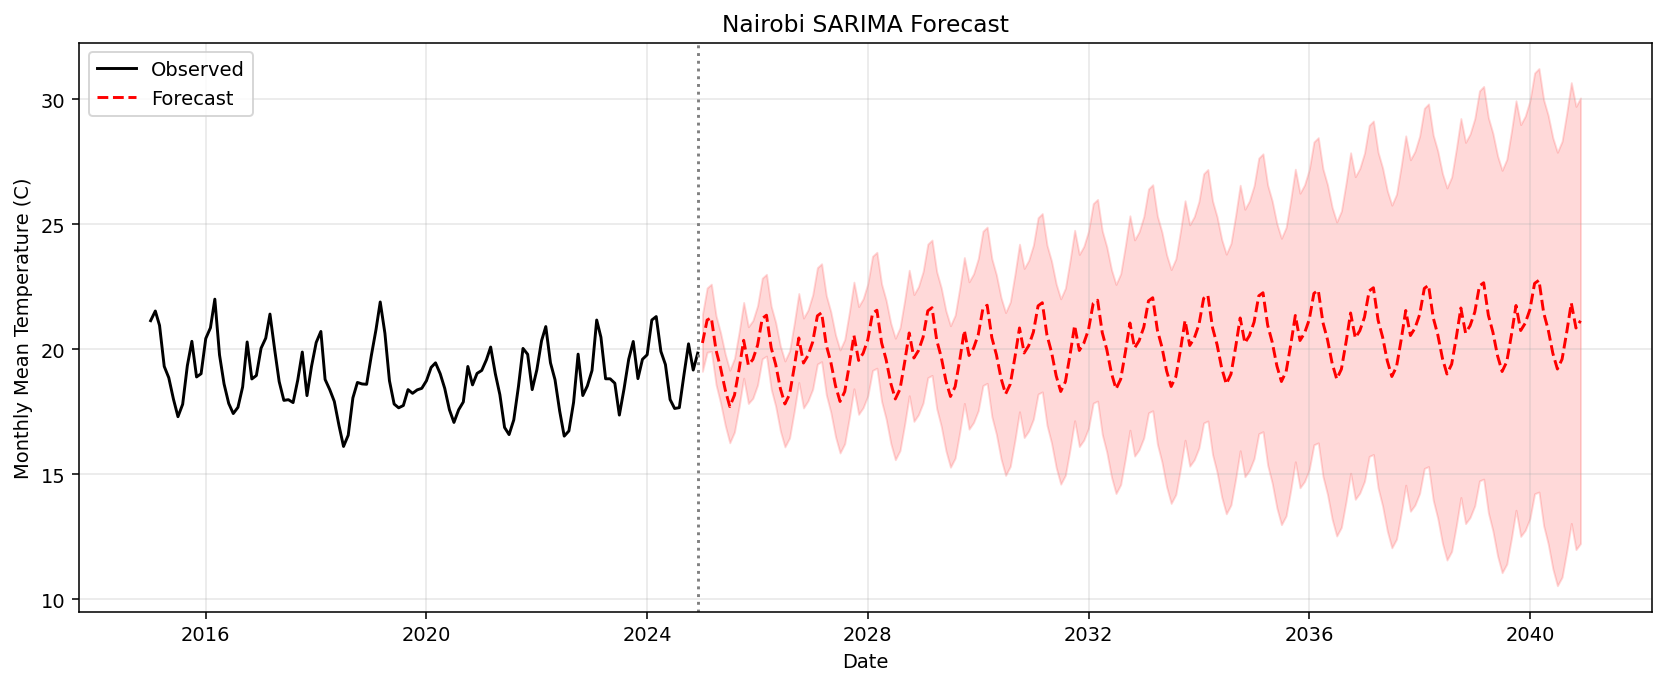

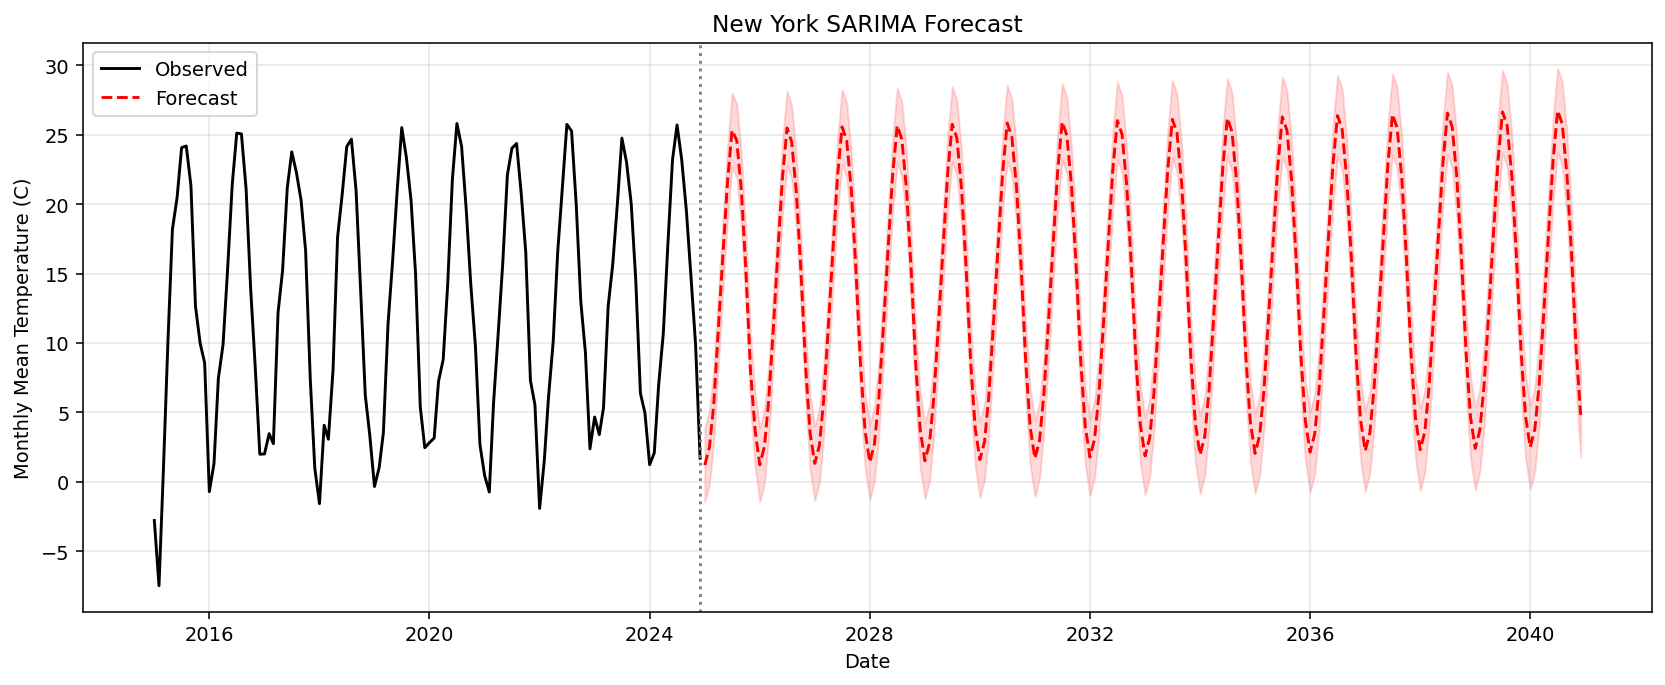

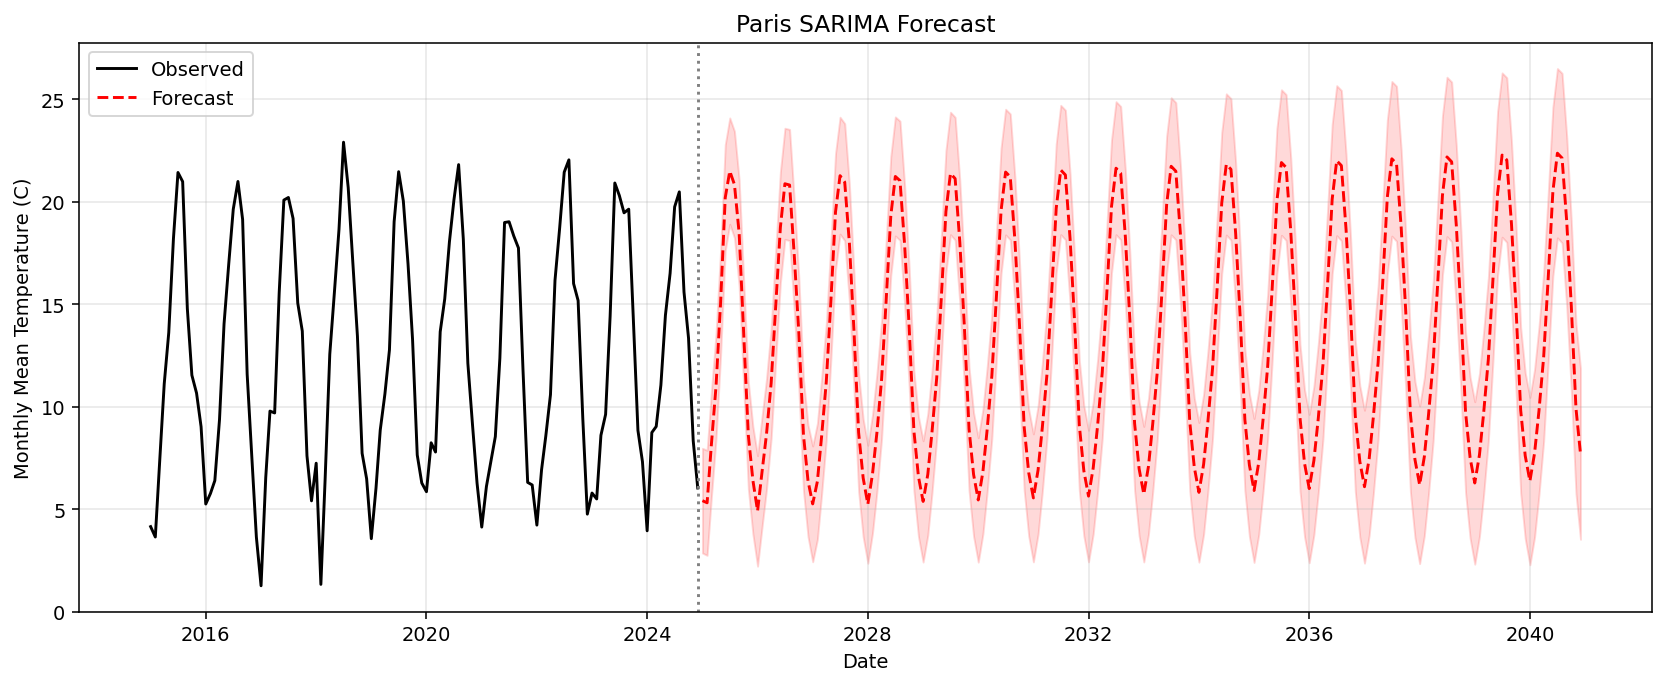

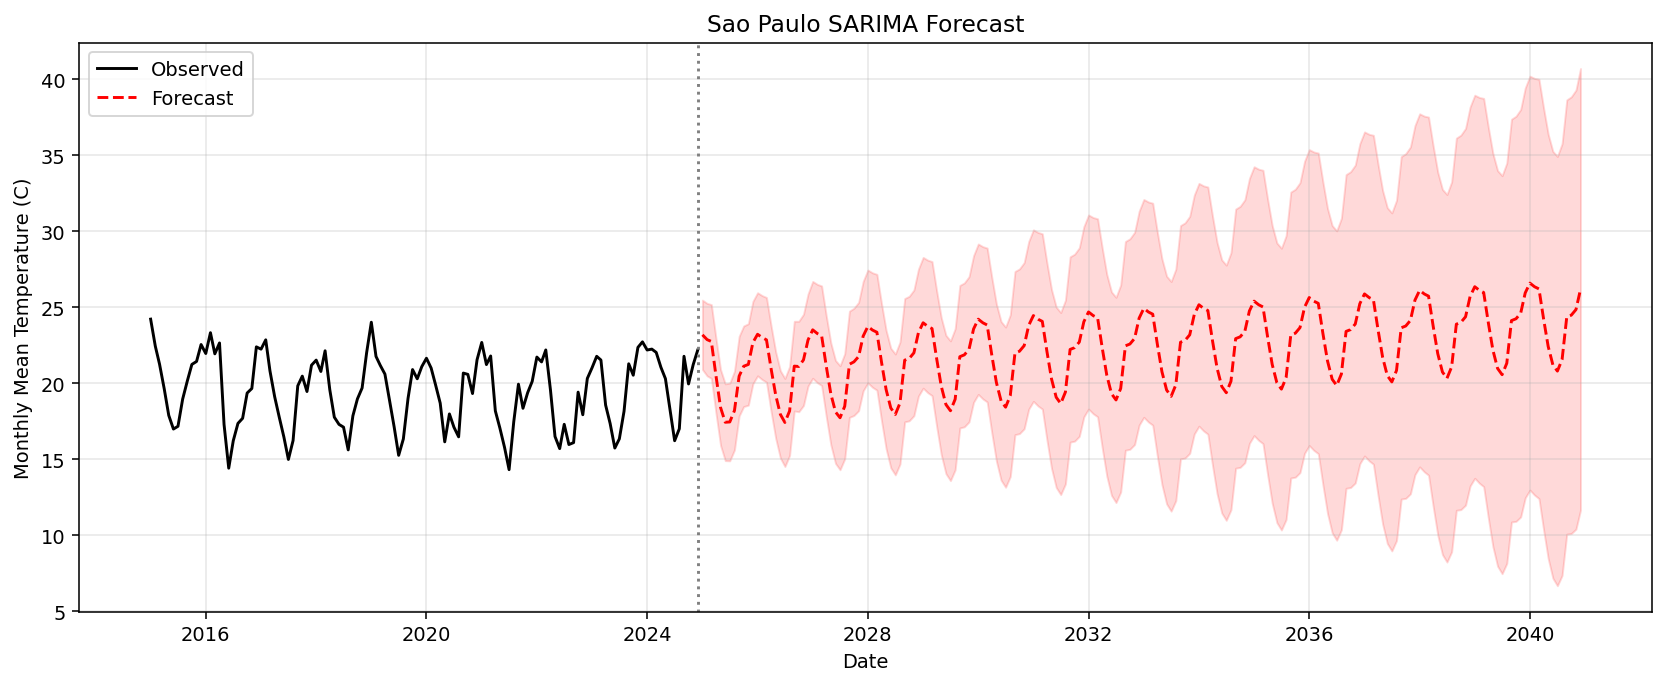

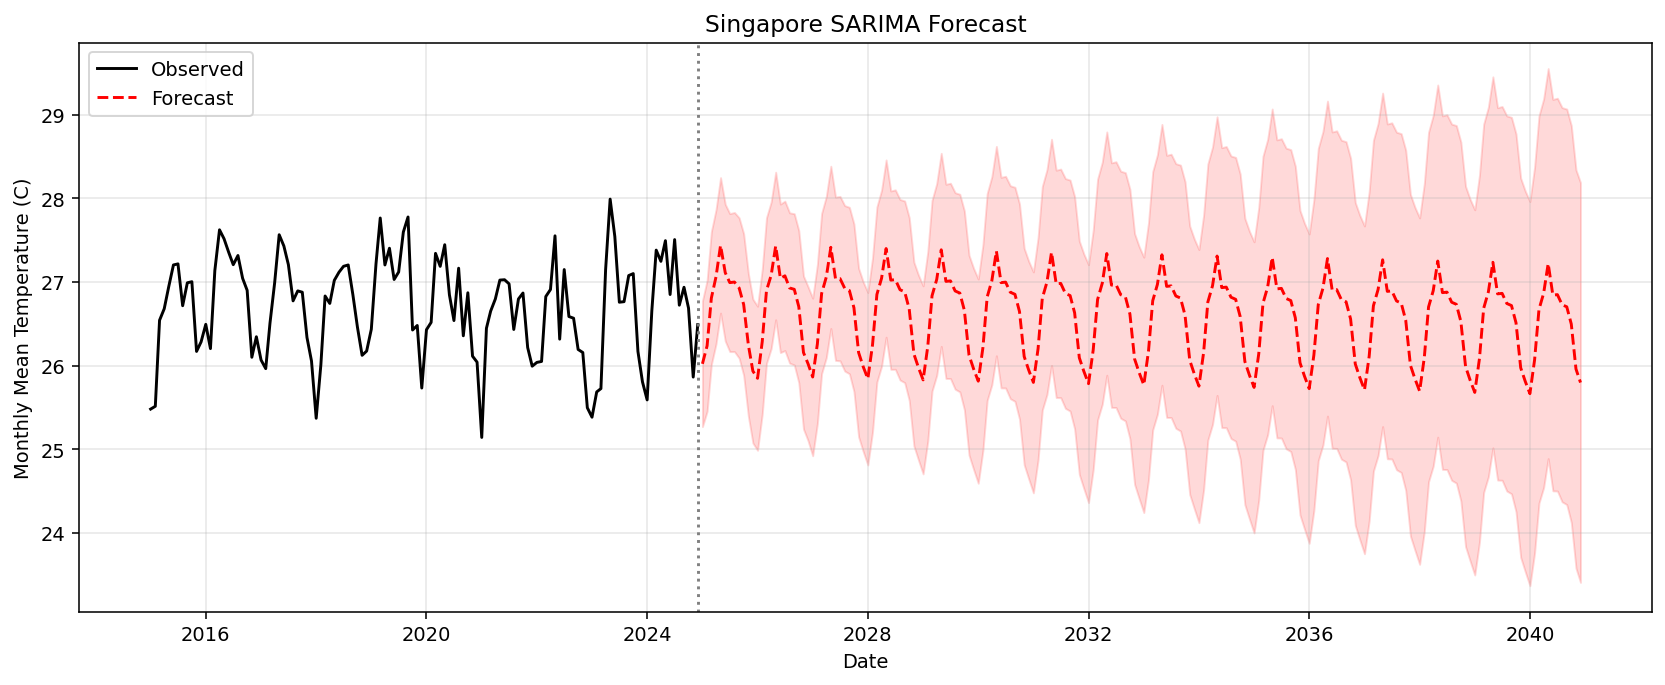

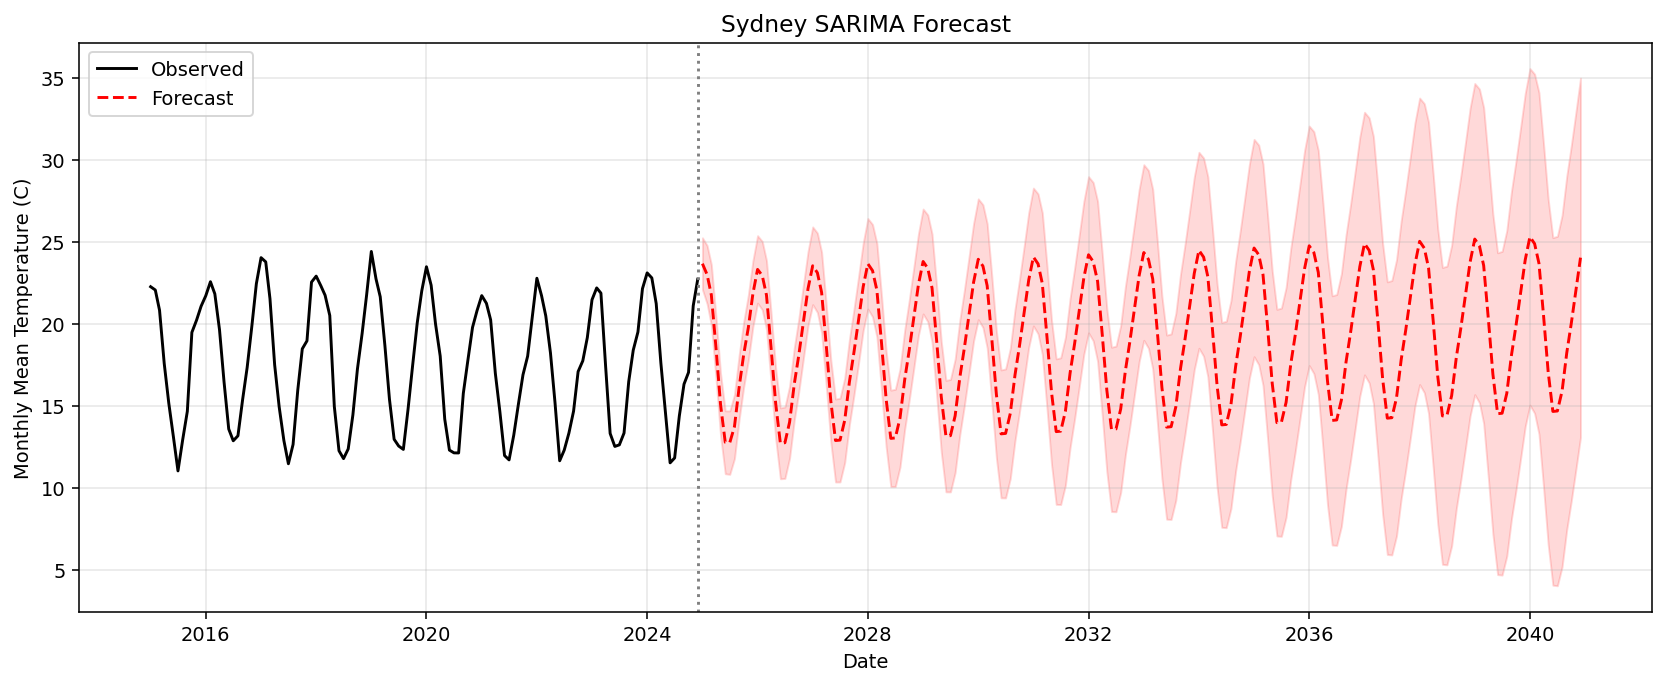

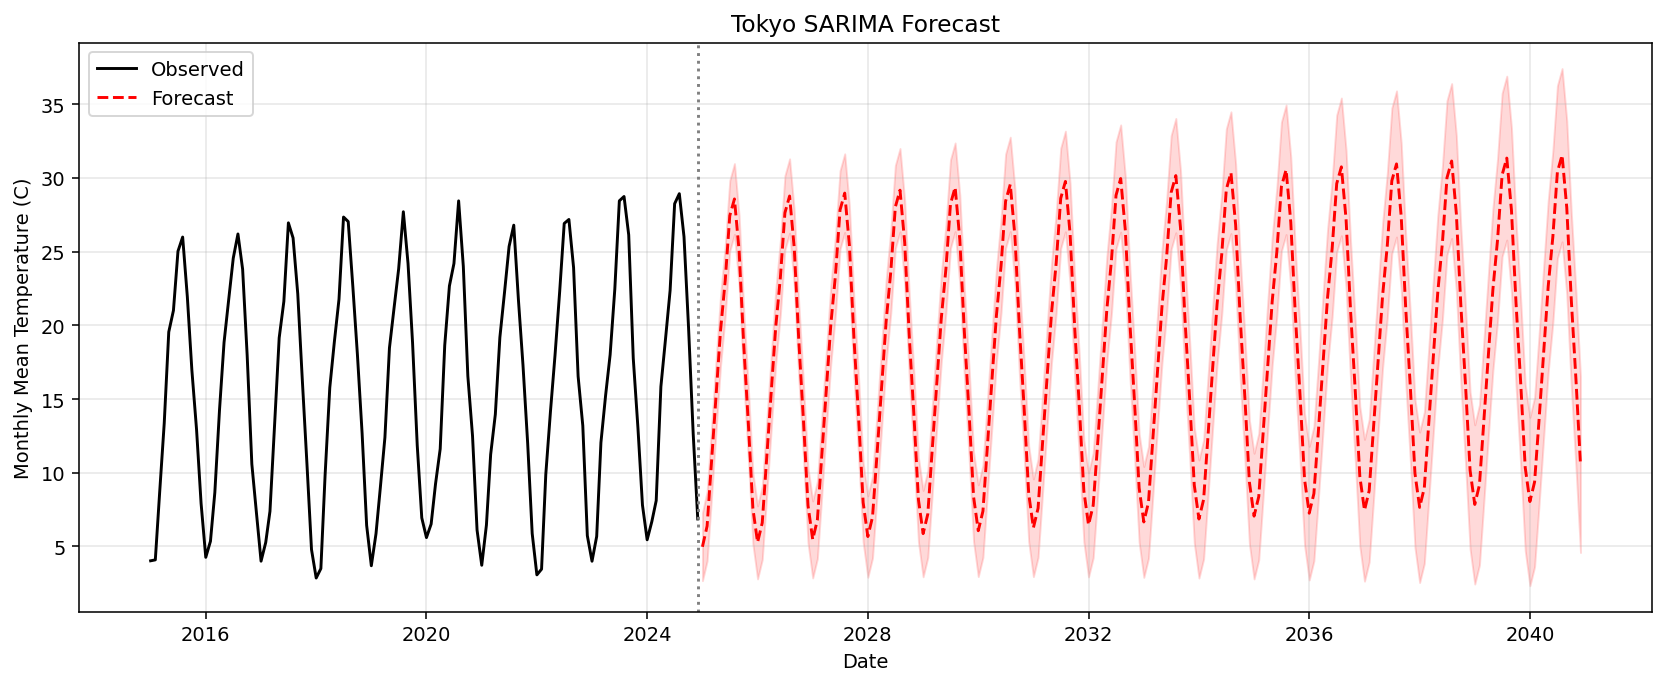

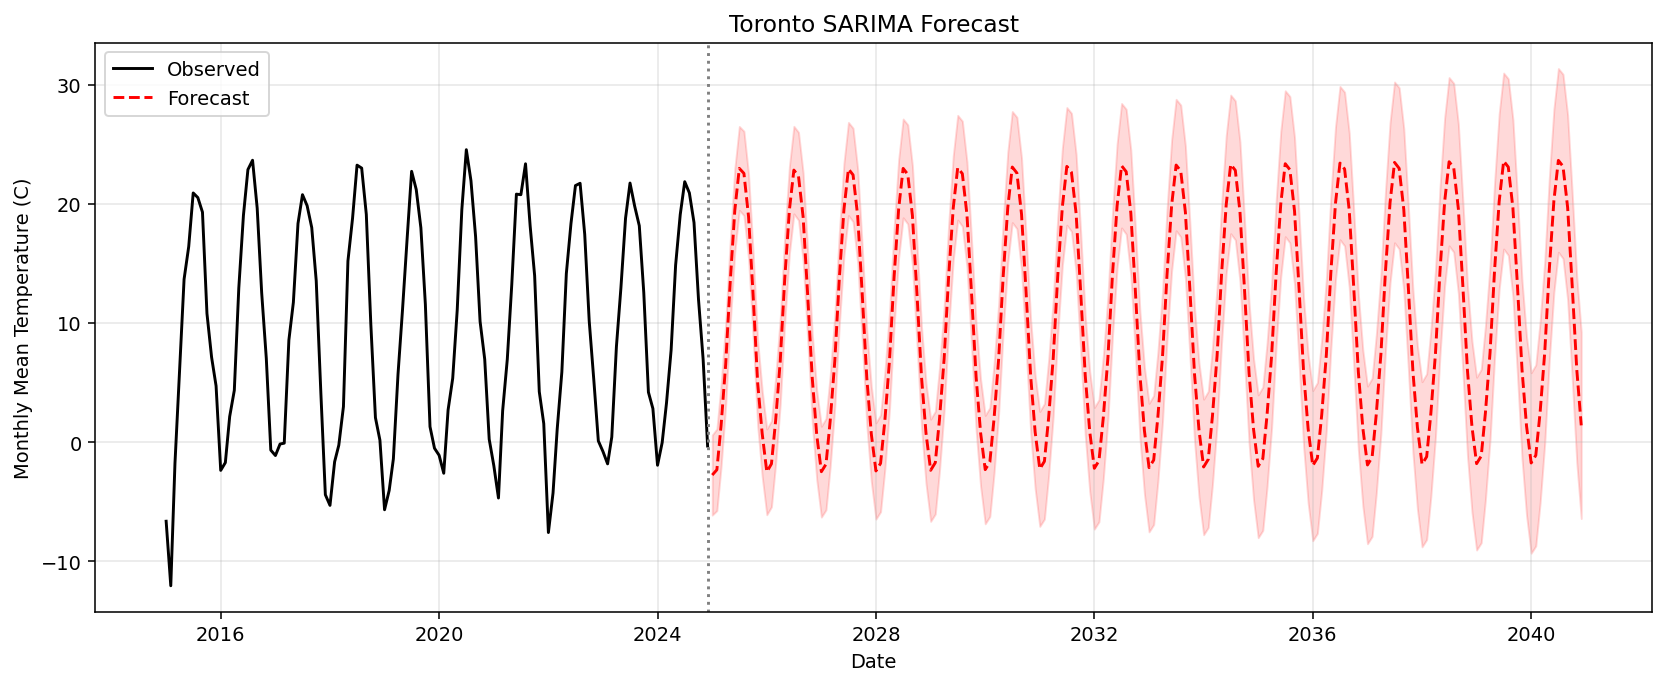

In [71]:
for city, data in df.groupby("city"):
    monthly_series = data.groupby(data["date"].dt.to_period("M"))["temp_mean"].mean()
    monthly_series.index = monthly_series.index.to_timestamp()
    monthly_series = monthly_series.resample("MS").mean().interpolate()

    train = monthly_series[: "2022-12-01"]

    try:
        model = SARIMAX(
            train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        final_model = SARIMAX(
            monthly_series,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        final_fit = final_model.fit(disp=False)

        future_steps = len(pd.date_range(
            start=monthly_series.index.max() + pd.DateOffset(months=1),
            end="2040-12-01",
            freq="MS"
        ))

        future_forecast_obj = final_fit.get_forecast(steps=future_steps)
        future_forecast = future_forecast_obj.predicted_mean
        future_ci = future_forecast_obj.conf_int()

        plt.figure(figsize=(12, 5))
        plt.plot(monthly_series.index, monthly_series.values, color="black", label="Observed")
        plt.plot(future_forecast.index, future_forecast.values, color="red", linestyle="--", label="Forecast")
        plt.fill_between(
            future_forecast.index,
            future_ci.iloc[:, 0],
            future_ci.iloc[:, 1],
            color="red",
            alpha=0.15
        )

        plt.axvline(pd.Timestamp("2024-12-01"), color="gray", linestyle=":")
        plt.title(f"{city} SARIMA Forecast")
        plt.xlabel("Date")
        plt.ylabel("Monthly Mean Temperature (C)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"{city}: SARIMA failed")
